# Ki keres >50K-t? – Data Science alapú feltáró elemzés

Ez a notebook **nem előrejelző modellt épít**, hanem  
**Data Science szemlélettel tárja fel**, hogy milyen tényezők kapcsolódnak ahhoz, hogy valaki az Adult Income adathalmazban **évi 50.000 dollár felett keres-e**.

## A notebook céljai
- megérteni a dataset szerkezetét és minőségét,
- megtisztítani a hibás vagy hiányos adatokat,
- vizualizálni az összefüggéseket a jövedelem és a magyarázó változók között,
- megérteni, mely tényezők (végzettség, munkaóra, beosztás, családi állapot stb.) kapcsolódnak leginkább a magas keresethez,
- SHAP segítségével **magyarázni**, nem predikálni.

## A használt Data Science pipeline lépései
1. **Adatbetöltés és megértés**
2. **Adattisztítás („?“, duplikációk, típuskavalkád)**
3. **Feltáró adatelemzés (EDA)**
4. **Mintázatok és összefüggések vizsgálata**
5. **Magyarázat és insight-ok megfogalmazása**

## Mit kapunk a végére?
Egy világos, adatokra épülő kép arról, hogy **kikre jellemző a magas jövedelem**,  
és hogy **milyen társadalmi-gazdasági tényezők** állnak a háttérben.

Ez a notebook kifejezetten a **Data Science gondolkodásmód** elsajátítását szolgálja —  
nem előrejelzést, hanem **megértést és magyarázatot**.


## Feature-ek jelentése az Adult Income adathalmazban

Az alábbiakban röviden összefoglaljuk, hogy az egyes oszlopok (feature-ök) mit jelentenek az Adult Income dataset-ben.  
Ez segít abban, hogy az elemzés során **értelmezni tudjuk az összefüggéseket**.

### Demográfiai adatok
- **age** – életkor (év)
- **sex** – nem (Male / Female)
- **race** – etnikai kategória (pl. White, Black, Asian-Pac-Islander)

### Iskolázottság / végzettség
- **education** – végzettség szövegesen (pl. Bachelors, HS-grad)
- **education-num** – végzettség számmal kódolva  
  *(minél nagyobb, annál magasabb szintű végzettség)*

### Családi / társadalmi státusz
- **marital-status** – családi állapot (pl. Married-civ-spouse, Never-married)
- **relationship** – háztartáson belüli szerep (pl. Husband, Wife, Not-in-family)

### Munkahely / foglalkoztatás
- **workclass** – foglalkoztatási forma  
  *(pl. Private, Self-emp-not-inc, Federal-gov, ? = hiányzó)*
- **occupation** – foglalkozás típusa  
  *(pl. Exec-managerial, Sales, Tech-support)*
- **hours-per-week** – heti munkaórák száma
- **fnlwgt** – súlyozó faktor a mintavételhez  
  *(nem fizikai mérés, statisztikai „szorzószám”, óvatosan értelmezendő!)*

### Ország / származás
- **native-country** – származási ország  
  *(pl. United-States, Mexico, ? = hiányzó)*

### Pénzügyi adatok
- **capital-gain** – tőkenyereség az adott évben  
- **capital-loss** – tőkeveszteség az adott évben

### Célváltozó
- **income** – jövedelmi kategória  
  - `<=50K`  → évi 50 000 USD alatt  
  - `>50K`   → évi 50 000 USD felett

### Megjegyzés
Az Adult Income dataset több heterogén, hiányos és szélsőséges változót tartalmaz (pl. `fnlwgt`, `capital-gain`, `?` értékek), ezért elemzése kifejezetten jó példa a valódi Data Science problémák megértésére.


In [1]:
# --- Könyvtárak betöltése ---
import pandas as pd
import numpy as np

# A dataset betöltése az OpenML-ről (publikus adatforrás)
from sklearn.datasets import fetch_openml

# --- Adult Income adathalmaz betöltése ---
adult = fetch_openml("adult", version=2, as_frame=True)
df = adult.frame.copy()   # saját példány, hogy ne módosítsuk az eredetit

In [2]:
# --- Alap információk az adathalmazról ---
print("Adatsorok és oszlopok száma:", df.shape)

print("\nOszlopnevek:")
print(df.columns.tolist())

print("\nAdathalmaz szerkezete:")
df.info()

Adatsorok és oszlopok száma: (48842, 15)

Oszlopnevek:
['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'class']

Adathalmaz szerkezete:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-

In [3]:
# --- Az első 5 sor megtekintése ---
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:
# --- Numerikus változók alap statisztikái ---
print("Numerikus változók statisztikája:")
df.describe()


Numerikus változók statisztikája:


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


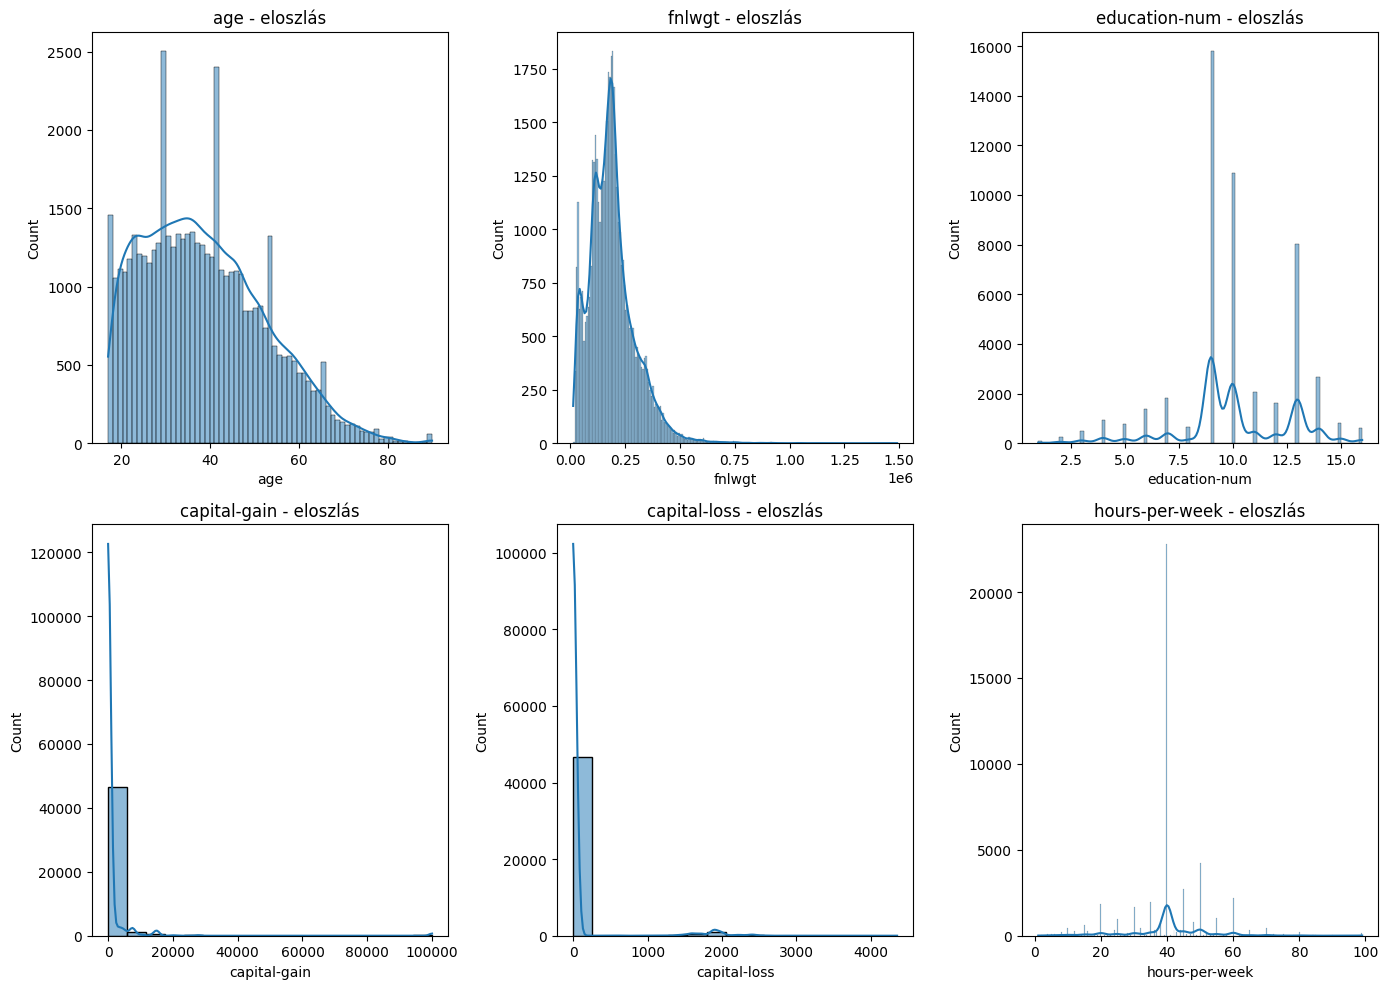

In [6]:
# --- Numerikus változók eloszlásának vizualizálása ---
# A hallgatók számára sokkal könnyebb értelmezni a boxplotokat és hisztogramokat.

import matplotlib.pyplot as plt
import seaborn as sns

# Kiválasztjuk a numerikus oszlopokat
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Hisztogramok minden numerikus változóra
plt.figure(figsize=(14, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} - eloszlás")
plt.tight_layout()
plt.show()


In [72]:
# Átlagéletkor jövedelmi kategóriánként
df.groupby("class")["age"].mean().sort_values()


/tmp/ipython-input-1250210977.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("class")["age"].mean().sort_values()


,age
class,
<=50K,36.872184
>50K,44.275178


In [73]:
# Óraszám jövedelem szerint
df.groupby("class")["hours-per-week"].mean()


/tmp/ipython-input-2034736574.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("class")["hours-per-week"].mean()


,hours-per-week
class,
<=50K,38.840048
>50K,45.452896


In [74]:
# Nők vs férfiak aránya jövedelem szerint
df.groupby("sex")["class"].apply(lambda x: (x==">50K").mean())


/tmp/ipython-input-2084481038.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("sex")["class"].apply(lambda x: (x==">50K").mean())


,class
sex,
Female,0.109251
Male,0.303767


In [75]:
# Jövedelem arány végzettségenként (nem normalizált)
df.groupby("education")["class"].apply(lambda x: (x==">50K").mean()).sort_values()


/tmp/ipython-input-4132483088.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("education")["class"].apply(lambda x: (x==">50K").mean()).sort_values()


,class
education,
Preschool,0.012048
1st-4th,0.032389
11th,0.050773
5th-6th,0.053045
9th,0.054233
10th,0.062635
7th-8th,0.064921
12th,0.073059
HS-grad,0.158578


In [76]:
# Jövedelem arány foglalkozásonként
df.groupby("occupation")["class"].apply(lambda x: (x==">50K").mean()).sort_values(ascending=False)


/tmp/ipython-input-3600772892.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("occupation")["class"].apply(lambda x: (x==">50K").mean()).sort_values(ascending=False)


,class
occupation,
Exec-managerial,0.477818
Prof-specialty,0.451069
Armed-Forces,0.333333
Protective-serv,0.313327
Tech-support,0.290456
Sales,0.267987
Craft-repair,0.226276
Transport-moving,0.204246
Adm-clerical,0.136874


In [77]:
# --- >50K arány foglalkozásonként, külön férfiakra és nőkre ---

occupation_income_gender = (
    df.groupby(["sex", "occupation"])["class"]
      .apply(lambda x: (x == ">50K").mean())
      .unstack(level=0)   # külön oszlop a férfi-nő
      .fillna(0)
      .sort_values(by="Male", ascending=False)
)

occupation_income_gender


/tmp/ipython-input-183694788.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["sex", "occupation"])["class"]


sex,Female,Male
occupation,,
Exec-managerial,0.240847,0.573306
Prof-specialty,0.259590,0.560305
Tech-support,0.119217,0.399321
Sales,0.068824,0.377003
Protective-serv,0.122951,0.340302
Armed-Forces,0.000000,0.333333
Adm-clerical,0.081985,0.249186
Craft-repair,0.102167,0.233201
Transport-moving,0.102362,0.210054


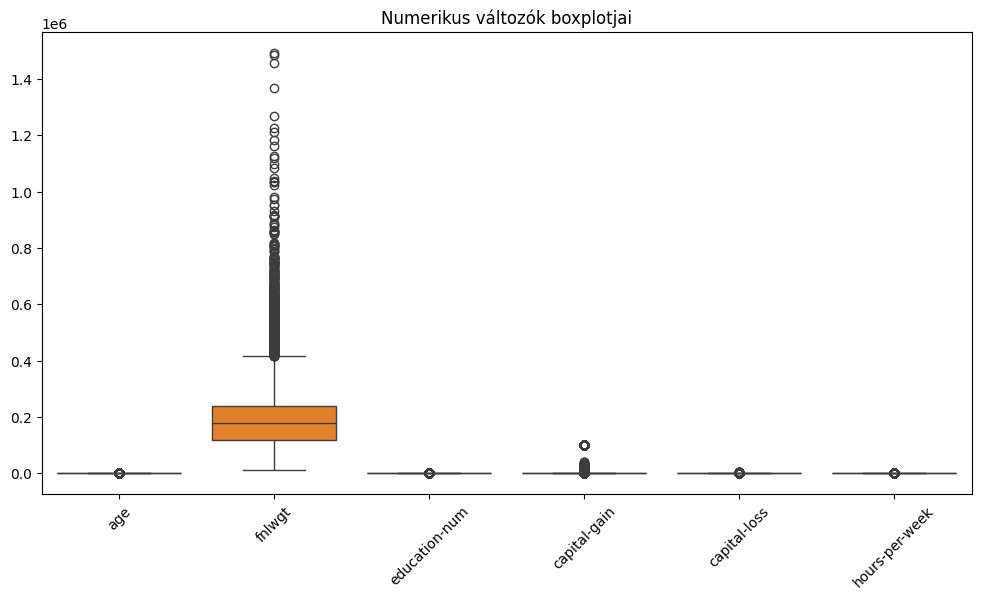

In [7]:
# --- Boxplotok a numerikus változókra ---
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numeric_cols])
plt.title("Numerikus változók boxplotjai")
plt.xticks(rotation=45)
plt.show()


## Miért torz a numerikus változók közös boxplotja?

A nyers adatokból készített közös boxplot első ránézésre „rossznak” tűnik, mert  
szinte **minden változó egy vékony csíkba szorul**, és csak az `fnlwgt` oszlop látszik.

Ez **nem hiba a kódban**, hanem teljesen természetes jelenség:

- az Adult Income adathalmaz numerikus változói **nagyon különböző skálán** vannak,  
- pl. az `age` 20–80 között mozog,  
- a `hours-per-week` 1–99 között,  
- a `capital-gain` többnyire 0, néha néhány ezer,  
- a `fnlwgt` viszont akár **1 millió feletti** értékeket tartalmaz.

Ezeket a skálákat **nem lehet egyetlen közös boxploton értelmesen ábrázolni**, mert az
óriási szóráskülönbségek összenyomják a többi változót.

### Mit lehet tenni?

Két tipikus Data Science megoldás létezik:

1. **Standardizáljuk** a numerikus változókat (z-score), így minden változó „egyforma skálára” kerül, és összehasonlíthatók lesznek.

2. **Külön-külön ábrázoljuk** őket subplotokban, mindegyik saját skálán, így látjuk a valódi eloszlásukat és outliereket.

Mindkét megoldást elkészítjük a következő cellákban.


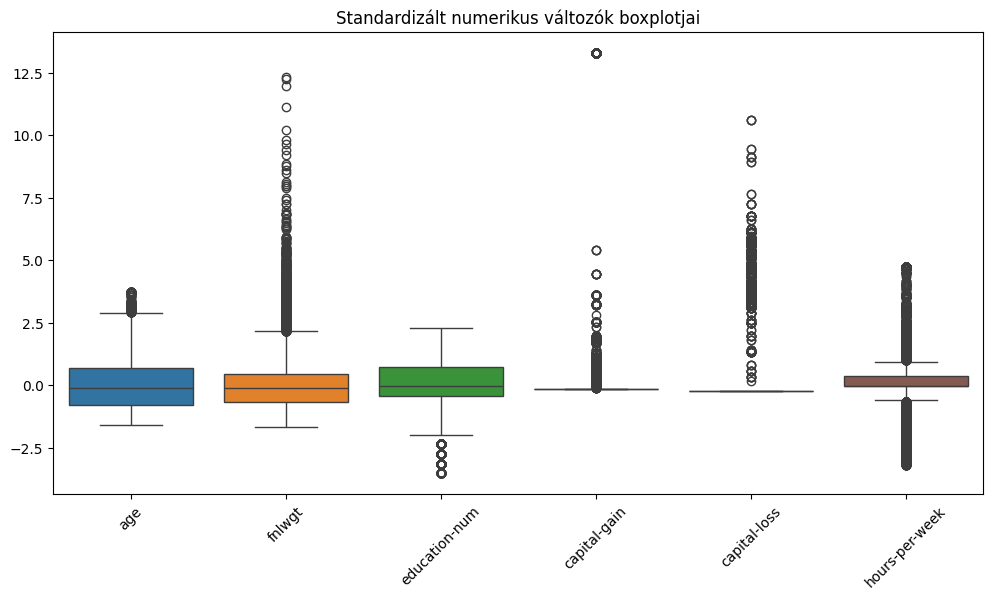

In [9]:
# --- Numerikus változók standardizálása, hogy együtt ábrázolhatók legyenek ---

from sklearn.preprocessing import StandardScaler

# csak a numerikus oszlopokat választjuk ki
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# skálázó létrehozása
scaler = StandardScaler()

# skálázott adat készítése
df_scaled = pd.DataFrame(
    scaler.fit_transform(df[numeric_cols]),
    columns=numeric_cols
)

# boxplot skálázott értékekre
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_scaled)
plt.title("Standardizált numerikus változók boxplotjai")
plt.xticks(rotation=45)
plt.show()


## Mit látunk a standardizált numerikus boxplotokon?

A fenti ábra már a *standardizált* numerikus változókat mutatja (z-score skálán).  
Ez azt jelenti, hogy minden változó:

- **0 átlagra** lett középre helyezve,  
- **1 szórásra** lett skálázva.  

Így végre **összehasonlíthatóvá vált**, hogy melyik változó
mennyire szóródik, és hol vannak a szélsőértékek (outlierek).

### Fő megfigyelések

1. **Az `age` és az `education-num` viszonylag stabil, kevés extrém értékkel**  
   – A box „kompakt”, a whiskerek rövidek → az emberek életkora és végzettségi szintje viszonylag kis szórással mozog.

2. **Az `fnlwgt` brutálisan szór, rengeteg outlierrel**  
   – Ez a változó valójában egy *súlyozó faktor*, nem valódi mért adat,  
     ezért nagyon sok extrém értéket tartalmaz → Data Science szempontból óvatosan kell kezelni.

3. **A `capital-gain` és `capital-loss` változók erősen torzak**  
   – A legtöbb embernek 0 a tőkenyeresége/vesztesége,  
     de néhány embernek nagyon magas → ezért rengeteg felfelé kilógó kör látható.  
   – Ezek a változók a dataset „ritka és extrém” típusú mezői.

4. **A `hours-per-week` erősen jobbra ferde**  
   – A legtöbben heti ~40 órát dolgoznak,  
     de vannak extrém módon sokat dolgozók → 60–90+ óra.

### Miért fontos ez a Data Science-ben?

- Megtanuljuk, hogy ugyanazon skálán ábrázolni változókat **nem mindig értelmes**,  
  standardizálásra vagy külön subplotokra van szükség.
- Az outlierek azonnal látszanak → dönthetünk, hogy:
  - **megtartjuk**,  
  - **winsorizáljuk**,  
  - vagy **eltávolítjuk** őket.
- A szórás alapján látható, mely változók lesznek későbbi elemzésnél dominánsak.

Ez a lépés a Data Science egyik alapja:  
**előbb ismerjük meg az adat eloszlását, csak utána vonunk le következtetést.**


In [8]:
df.describe(include=['category'])


,workclass,education,marital-status,occupation,relationship,race,sex,native-country,class
count,46043,48842,48842,46033,48842,48842,48842,47985,48842
unique,8,16,7,14,6,5,2,41,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,33906,15784,22379,6172,19716,41762,32650,43832,37155


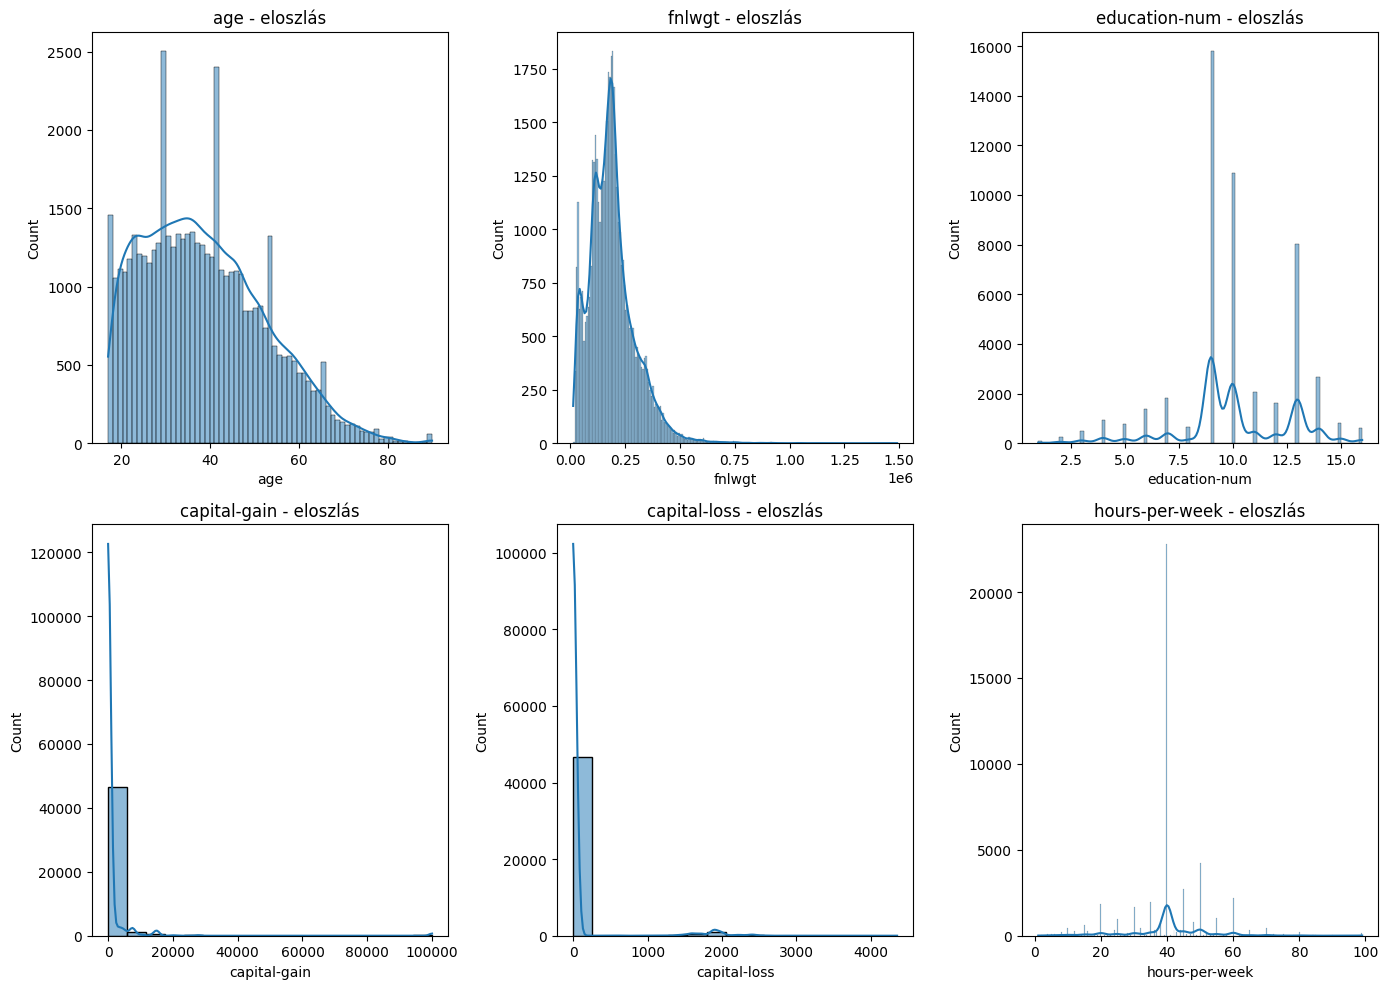

In [10]:
# --- Numerikus változók eloszlásának vizualizálása ---
# A hallgatók számára sokkal könnyebb értelmezni a boxplotokat és hisztogramokat.

import matplotlib.pyplot as plt
import seaborn as sns

# Kiválasztjuk a numerikus oszlopokat
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Hisztogramok minden numerikus változóra
plt.figure(figsize=(14, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} - eloszlás")
plt.tight_layout()
plt.show()

## Miért lehet szükség Box–Cox transzformációra?

A fenti hisztogramokon jól látszik, hogy több numerikus változó
(**fnlwgt**, **capital-gain**, **capital-loss**) erősen jobbra ferde (skewed).
Ez azt jelenti, hogy:

- a legtöbb érték nagyon alacsony,
- néhány extrém érték „elhúzza” az eloszlást,
- a boxplot tele van outlierekkel,
- az átlag és a szórás nem jó jellemzők egy ilyen eloszlásra,
- a statisztikai módszerek és távolság-alapú elemzések torzulnak.

Ilyenkor érdemes **eloszlás-normalizáló transzformációt** használni:

### Log-transzformáció  
Jól működik, ha a változó skálája nagy és sok a nulla alatti rész.

### Box–Cox transzformáció  
Ez egy automatikusan optimalizált hatványtranszformáció,  
amely a lehető leginkább normalizálja az eloszlást.

A Box–Cox használatához viszont **pozitív értékekre** van szükség,  
ezért a 0-kat vagy el kell tolni (+1), vagy ki kell hagyni.

A következő cellában megmutatjuk, hogyan néz ki a Box–Cox transzformáció
a `capital-gain` változóra, és hogyan javítja az eloszlás alakját.

Box–Cox lambda értéke: 0.15495657450932657


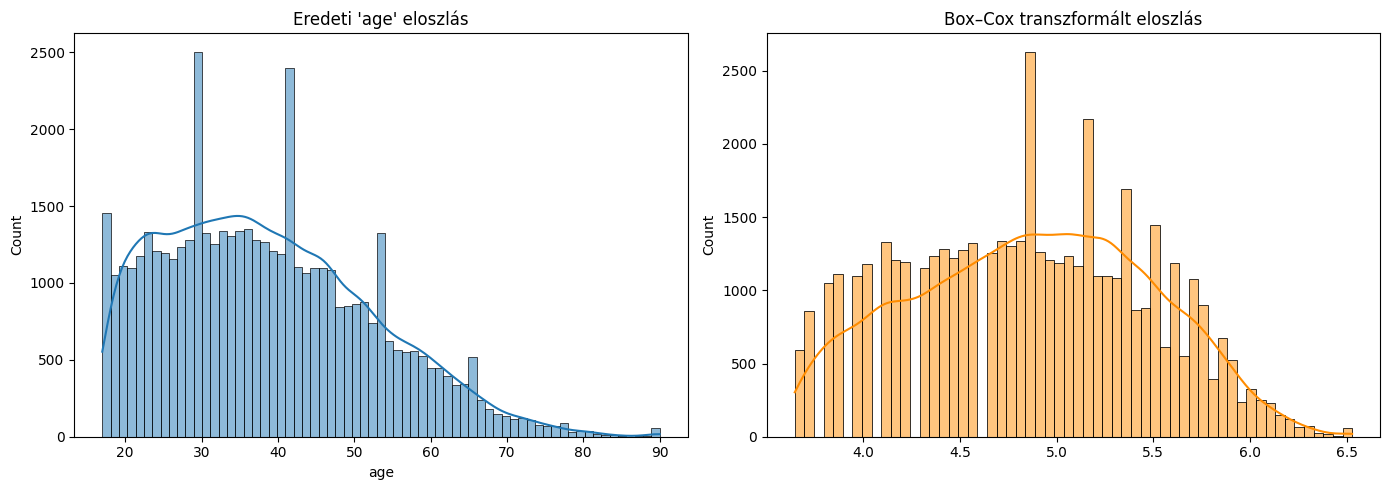

In [13]:
# --- Box–Cox transzformáció bemutatása ---
# Magyar kommentekkel

from scipy.stats import boxcox
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Válasszunk egy erősen ferde eloszlású numerikus mezőt, pl. 'age'
series = df['age']

# A Box–Cox csak pozitív értékekre működik → a 0 értékeket eltoljuk +1-gyel
series_shifted = series + 1

# Box–Cox transzformáció végrehajtása
transformed, lambda_value = boxcox(series_shifted)

print("Box–Cox lambda értéke:", lambda_value)

# --- Eredeti vs transzformált eloszlások vizualizálása ---
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(series, kde=True)
plt.title("Eredeti 'age' eloszlás")

plt.subplot(1, 2, 2)
sns.histplot(transformed, kde=True, color='darkorange')
plt.title("Box–Cox transzformált eloszlás")

plt.tight_layout()
plt.show()



## Miért hasznos a Box–Cox transzformáció?

A fenti ábrán az `age` változó *eredeti* és *Box–Cox transzformált* eloszlását látjuk.  
A cél nem az, hogy az adat „szebb legyen”, hanem hogy **használhatóbb legyen az elemzéshez**.

### 1. Az eredeti eloszlás ferde (skewed)
Az `age` változó jobbra ferde:
- a legtöbb ember 25–45 év közötti,
- kevés a nagyon fiatal vagy nagyon idős,
- emiatt az átlag és a szórás **nem reprezentálja jól** az eloszlást.

Ez tipikus Data Science probléma.

### 2. A ferdeség torzítja a statisztikai módszereket
Sok módszer érzékeny az eloszlás alakjára:
- korrelációk,
- távolság-alapú módszerek (kNN, clustering),
- regressziók,
- outlier-detekció,
- skálázott vizualizációk.

Ha az eloszlás nagyon ferde, a szélső értékek túl nagy hatással vannak.

### 3. A Box–Cox transzformáció „normalizálja” az eloszlást
A Box–Cox egy optimalizált hatványtranszformáció, amely:
- csökkenti a ferdeséget,
- közelebb hozza az eloszlást a normál eloszláshoz,
- kiegyensúlyozza a skálát,
- stabilabbá teszi a további elemzést.

Ez **nem módosítja a rangsorokat**, csak a skálát alakítja át.

### 4. Mit nyerünk a transzformációval?
- Jobban látszik az adat valódi szerkezete  
- Kisebb hatása van az extrém értékeknek  
- Értelmezhetőbb statisztikákat kapunk  
- A modellek és elemzések kevésbé lesznek torzak  
- Könnyebben összehasonlítható más változókkal

### Összefoglalás
A Box–Cox transzformáció arra szolgál, hogy  
**egy ferde, torzított eloszlásból egy kiegyensúlyozottabb, elemezhetőbb eloszlást** kapjunk.

Ez egy tipikus Data Science előfeldolgozási lépés, különösen akkor, ha:
- extrém értékek vannak,
- nagyon ferde a változó,
- a módszer érzékeny a skálára.

A következő elemzési lépések (EDA, clustering, távolságmérés, regresszió) így sokkal stabilabb és érthetőbb eredményt adnak.


## AGE oszlop összehasonlítása: eredeti, standardizált és Box–Cox transzformált

Az `age` változó három különböző formáját hasonlítjuk össze:

1. **Eredeti eloszlás**  
   - jobbra ferde, hosszú „farka” van  
   - a szélső értékek nagy hatással vannak  
   - a statisztikák nem teljesen reprezentatívak

2. **Standardizált (z-score) eloszlás**  
   - átlag = 0, szórás = 1  
   - de az eloszlás *alakja* nem változik  
   - a ferdeség és az outlierek problémája megmarad

3. **Box–Cox transzformált eloszlás**  
   - csökken a ferdeség  
   - a szélsőértékek hatása kisebb  
   - az eloszlás „szabályosabb”, közelebb kerül a normálishoz  
   - a statisztikai módszerek és modellek kevésbé torzulnak

Ez a példa jól mutatja, hogy **a skálázás nem oldja meg a ferdeség problémáját**,  
míg a **Box–Cox igen**.


In [15]:
# --- AGE oszlop előkészítése három formában ---
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.stats import boxcox

age_raw = df['age'].copy()

# Standardizált AGE
scaler = StandardScaler()
age_scaled = scaler.fit_transform(df[['age']]).flatten()

# Box–Cox transzformáció (pozitív +1 eltolás nem szükséges, mert nincs 0)
age_boxcox, age_lambda = boxcox(df['age'])

print("Box–Cox lambda értéke az AGE oszlopra:", age_lambda)


Box–Cox lambda értéke az AGE oszlopra: 0.17478290277032177


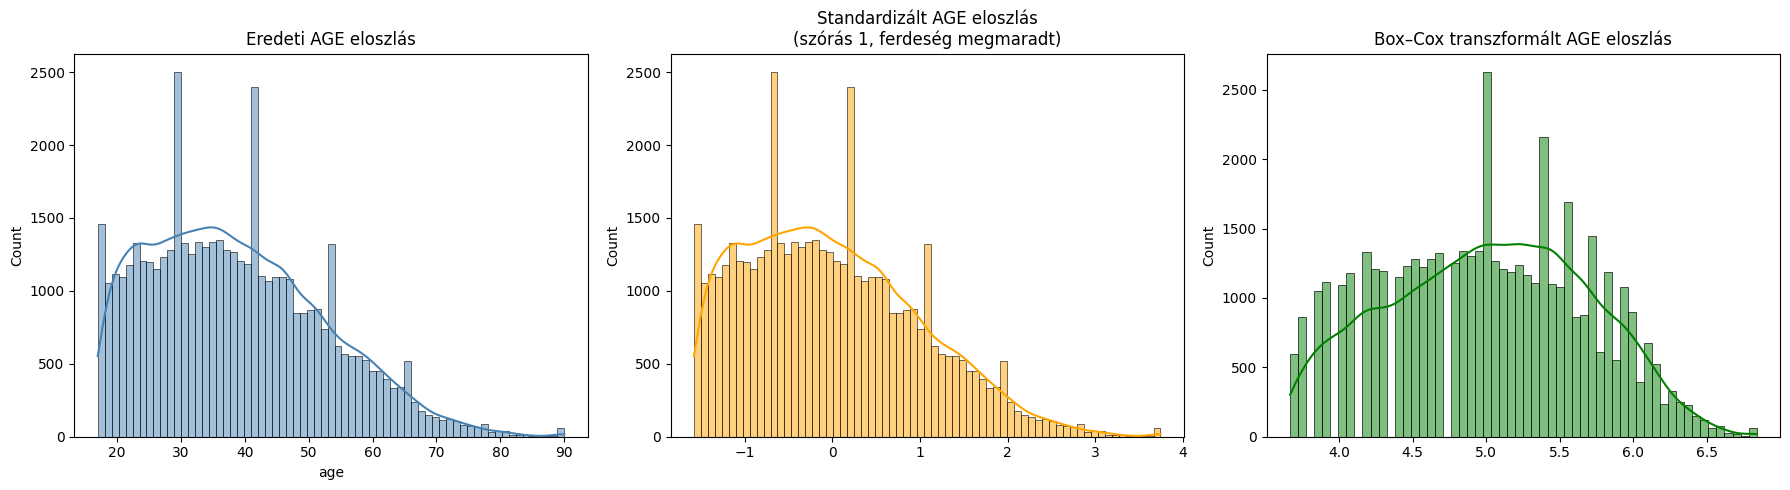

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 5))

# --- Eredeti eloszlás ---
plt.subplot(1, 3, 1)
sns.histplot(age_raw, kde=True, color='steelblue')
plt.title("Eredeti AGE eloszlás")

# --- Standardizált eloszlás ---
plt.subplot(1, 3, 2)
sns.histplot(age_scaled, kde=True, color='orange')
plt.title("Standardizált AGE eloszlás\n(szórás 1, ferdeség megmaradt)")

# --- Box–Cox eloszlás ---
plt.subplot(1, 3, 3)
sns.histplot(age_boxcox, kde=True, color='green')
plt.title("Box–Cox transzformált AGE eloszlás")

plt.tight_layout()
plt.show()


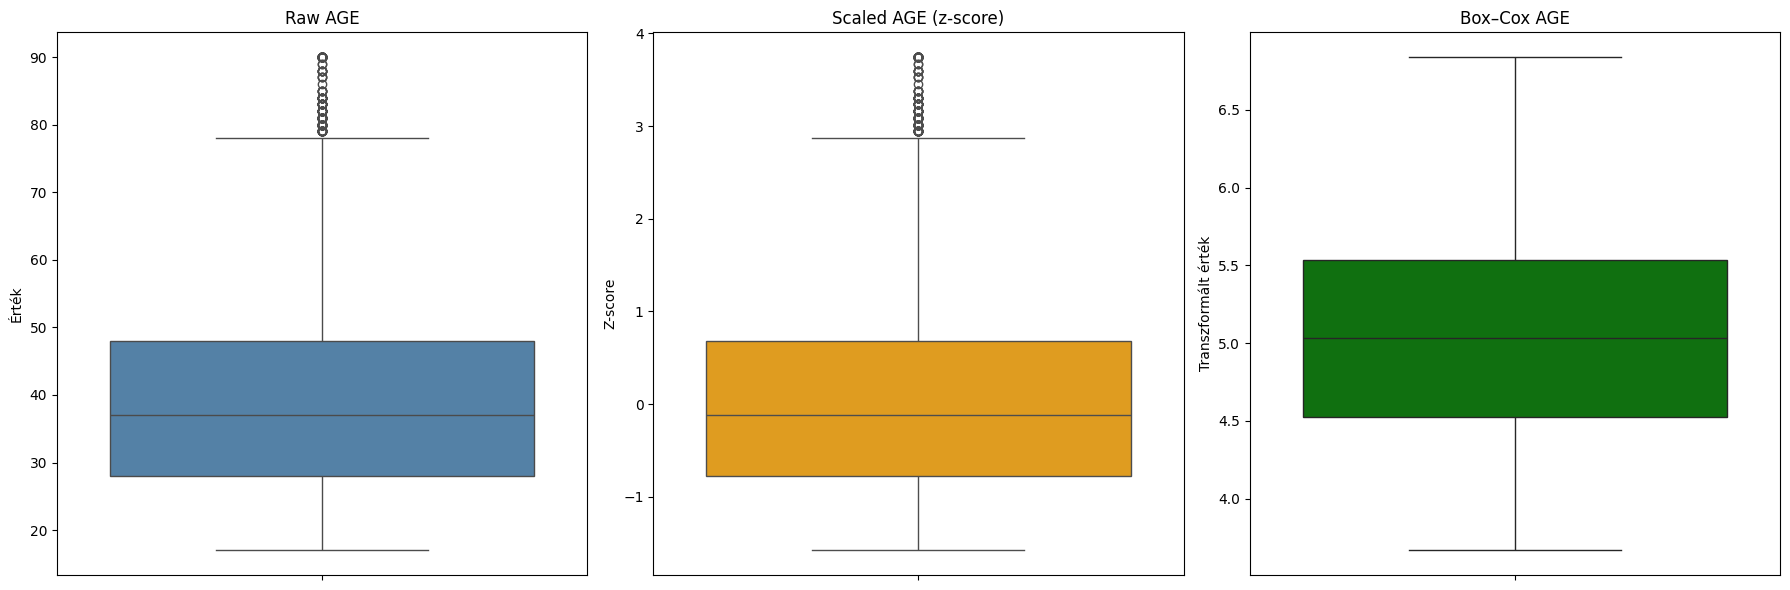

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 6))

# --- 1. Eredeti AGE eloszlás (nyers adat) ---
plt.subplot(1, 3, 1)
sns.boxplot(y=age_raw, color='steelblue')
plt.title("Raw AGE")
plt.ylabel("Érték")

# --- 2. Standardizált AGE (z-score skála) ---
plt.subplot(1, 3, 2)
sns.boxplot(y=age_scaled, color='orange')
plt.title("Scaled AGE (z-score)")
plt.ylabel("Z-score")

# --- 3. Box–Cox transzformált AGE ---
plt.subplot(1, 3, 3)
sns.boxplot(y=age_boxcox, color='green')
plt.title("Box–Cox AGE")
plt.ylabel("Transzformált érték")

plt.tight_layout()
plt.show()



## Mit mutat ez a három boxplot valójában?

Ez az ábra remekül szemlélteti, hogy a különböző átalakítások hogyan hatnak
az `age` változó eloszlására és különösen a **szélső értékekre**.

### Miért fontos ez Data Science szempontból?

Sok elemző feladat — különösen a statisztikai módszerek, távolság-alapú algoritmusok,
klaszterezés, regresszió — érzékeny a ferde eloszlásokra és az outlierekre.

- A standardizálás **nem szünteti meg a ferdeséget**.  
- A Box–Cox **kiegyensúlyozza az eloszlást**, csökkenti az outlier-hatást,
  így stabilabb, kevésbé torzított elemzést tesz lehetővé.

Ez a három boxplot együtt kiváló példa arra, hogy:

- a nyers adat problémás lehet,
- a standardizálás nem javítja az eloszlás alakját,
- a Box–Cox viszont **tényleg kezelni tudja a ferdeséget**.

Ez az egyik legfontosabb előfeldolgozási tanulság a Data Science-ben.


## Kell-e outliert eltávolítani az AGE változóból?

A három boxplot összehasonlítása után úgy tűnhet, hogy a
Box–Cox transzformált `AGE` esetén „eltűntek” a szélső értékek.  
Fontos azonban megérteni, hogy **ez nem jelenti azt, hogy az adatból törölni kellene bármit**.

### Az eredeti AGE eloszlásban vannak szélső értékek
A 70–90 év közötti értékek **statisztikai értelemben** outliernek minősülhetnek,
mert ritkák és messze esnek a mediántól.

DE:  
**ezek valós, létező emberek és érvényes adatok** → nem hibák.

Ezért az outlier-dobás statisztikai szempontból rossz ötlet lenne.


### Következtetés
- Az `AGE` változón **nem kell outliert eltávolítani**,  
  mert a szélső értékek valós, érvényes embercsoportot jelentenek.
- A Box–Cox transzformáció jó, ha:
  - statisztikai elemzést végzünk,  
  - modellezünk,  
  - távolság-alapú módszereket alkalmazunk,  
  - csökkenteni akarjuk az extrém értékek torzító hatását.

### Mikor kellene mégis eltávolítani?
Csak akkor, ha:
- hibás adat (pl. „200 éves” ember),
- eleve kizárjuk az adott elemzésből a 80–90 éves korosztályt.

Az Adult Income datasetben egyik sem igaz.


## TOP–10 kategória vizsgálata minden kategóriás oszlopra

A kategorikus változókat mindenképp érdemes tovább elemezni, mert az Adult Income datasetben valójában ezek hordozzák a legtöbb információt a jövedelemmel kapcsolatban.

A numerikus mezők csak kis részben magyarázzák, hogy ki keres >50K-t.
A kategóriások a kulcs.

A Data Science-ben ez egy nagyon jó pont arra, hogy megmutasd:

- “A kategóriás változókat nem elég megszámolni.”
- “A kategóriák közötti különbségek adják a legtöbb insightot.”

Nézzük, mit érdemes csinálni velük EDA céljából.

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Kiválasztjuk a kategóriás mezőket ---
cat_cols = df.select_dtypes(include=['category']).columns
cat_cols


Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'class'],
      dtype='object')

/tmp/ipython-input-308251467.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.index.astype(str), y=top10.values, palette="viridis")


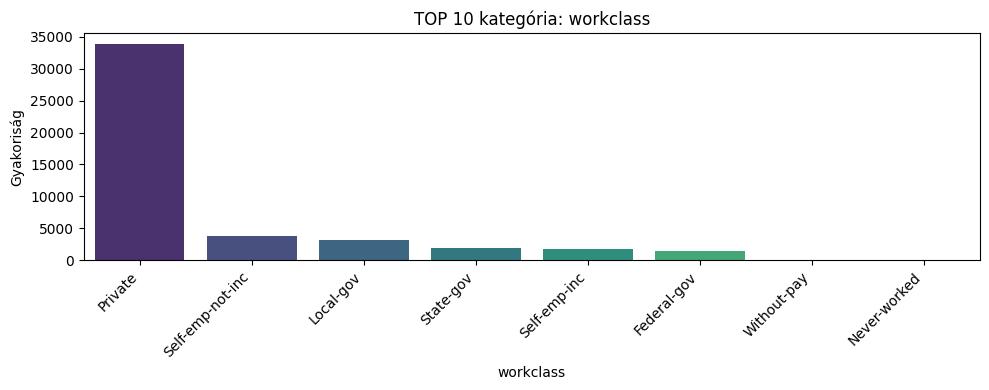

/tmp/ipython-input-308251467.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.index.astype(str), y=top10.values, palette="viridis")


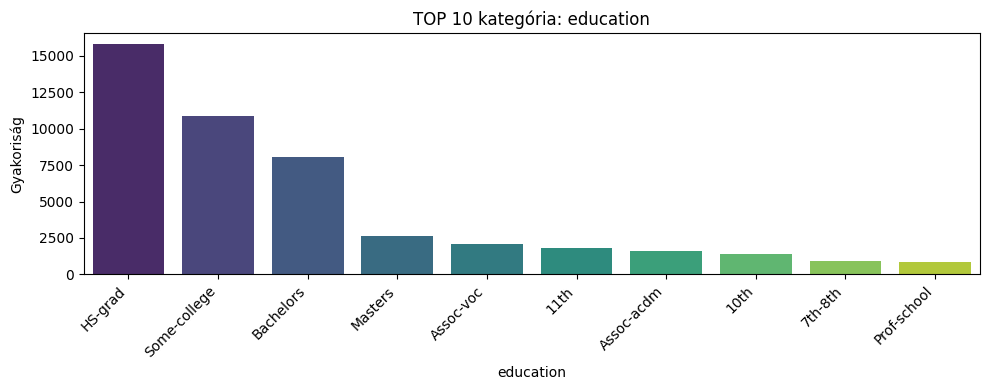

/tmp/ipython-input-308251467.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.index.astype(str), y=top10.values, palette="viridis")


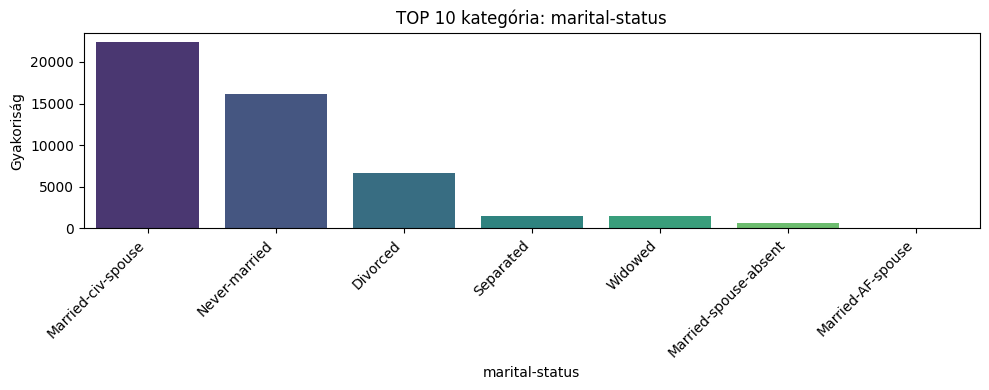

/tmp/ipython-input-308251467.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.index.astype(str), y=top10.values, palette="viridis")


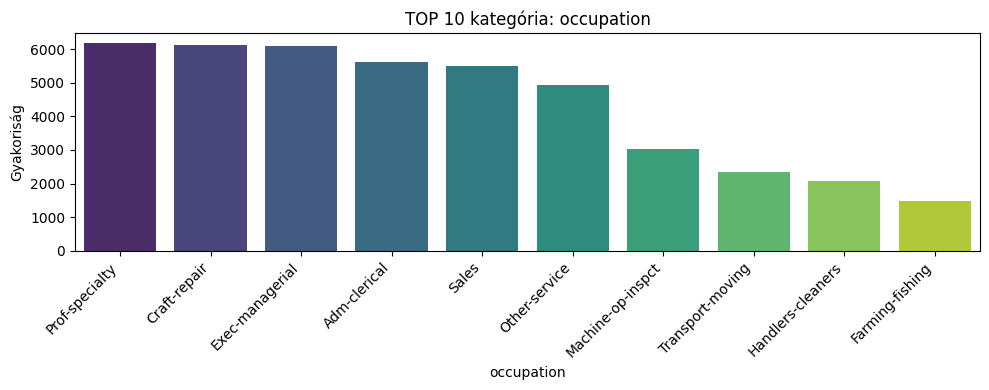

/tmp/ipython-input-308251467.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.index.astype(str), y=top10.values, palette="viridis")


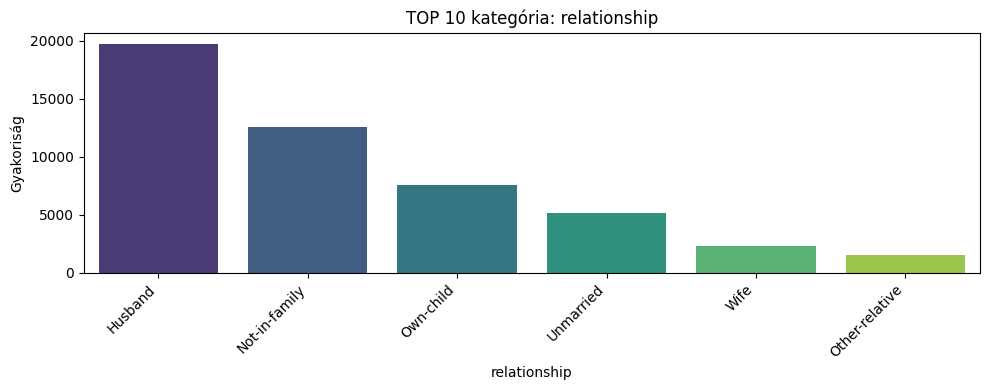

/tmp/ipython-input-308251467.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.index.astype(str), y=top10.values, palette="viridis")


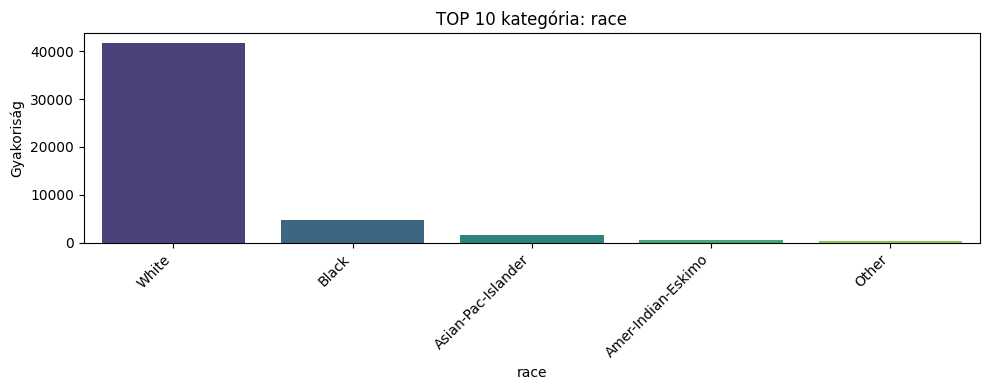

/tmp/ipython-input-308251467.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.index.astype(str), y=top10.values, palette="viridis")


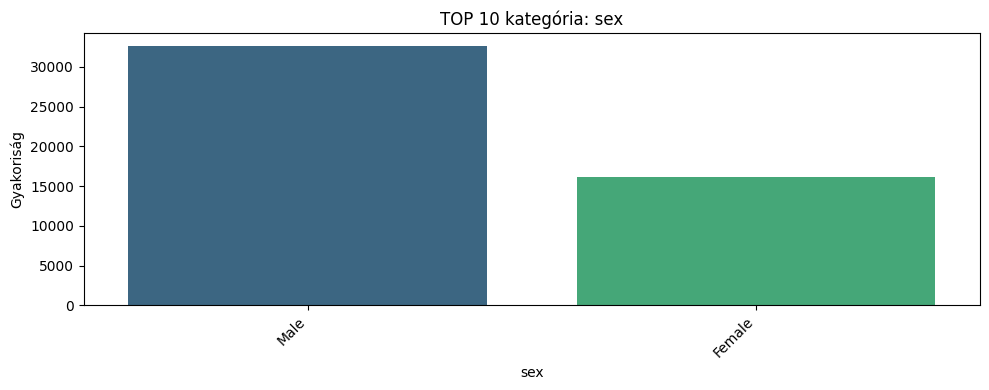

/tmp/ipython-input-308251467.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.index.astype(str), y=top10.values, palette="viridis")


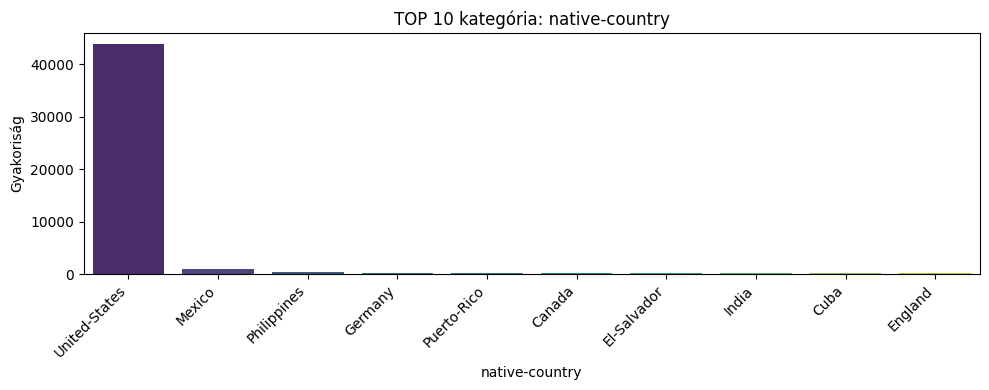

/tmp/ipython-input-308251467.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.index.astype(str), y=top10.values, palette="viridis")


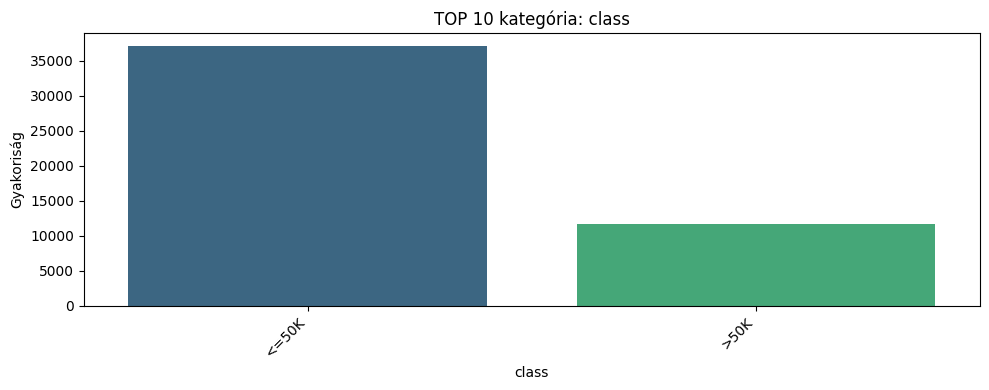

In [22]:
# ---  TOP 10 kategória vizualizáció minden kategóriás mezőn ---
# Ez remek áttekintést ad, hogy mely kategóriák dominálnak az adatban.

for col in cat_cols:
    plt.figure(figsize=(10, 4))

    # Csak a 10 leggyakoribb kategóriát mutatjuk
    top10 = df[col].value_counts().head(10)

    sns.barplot(x=top10.index.astype(str), y=top10.values, palette="viridis")
    plt.title(f"TOP 10 kategória: {col}")
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Gyakoriság")
    plt.tight_layout()
    plt.show()


## Kategória vs Income – Countplot (<=50K vs >50K)

Ez fogja megmutatni:
- melyik kategóriákban magasabb a >50K arány,
- mely társadalmi csoportoknál látható jövedelmi különbség,
- hogyan oszlik meg a jövedelem a különböző kategóriák között.

Ez az Adult Income dataset legtanulságosabb része.

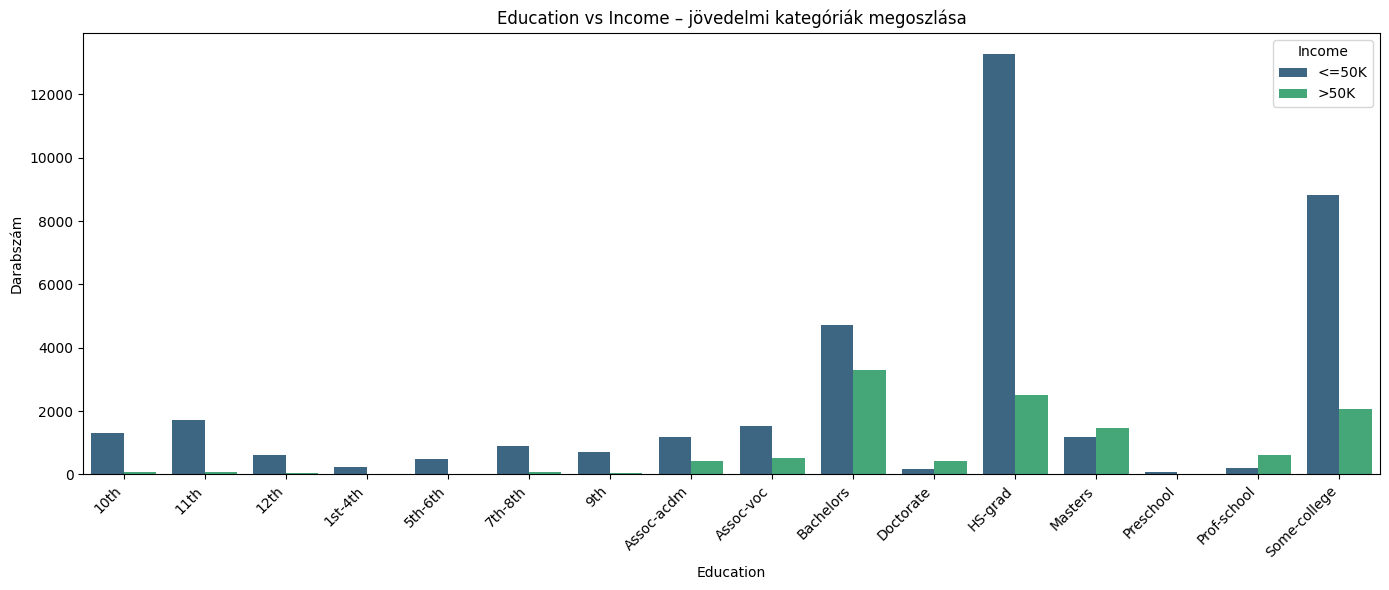

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Countplot - jövedelem kategóriánkénti eloszlása EDUCATION alapján
sns.countplot(
    data=df,
    x='education',
    hue='class',
    palette='viridis'
)

plt.title("Education vs Income – jövedelmi kategóriák megoszlása")
plt.xticks(rotation=45, ha='right')
plt.xlabel("Education")
plt.ylabel("Darabszám")
plt.legend(title="Income")
plt.tight_layout()
plt.show()


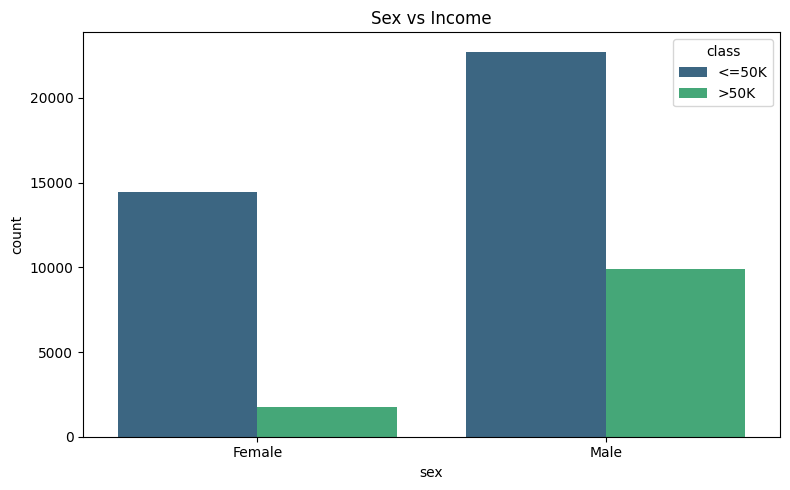

In [26]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x='sex',
    hue='class',
    palette='viridis'
)
plt.title("Sex vs Income")
plt.tight_layout()
plt.show()


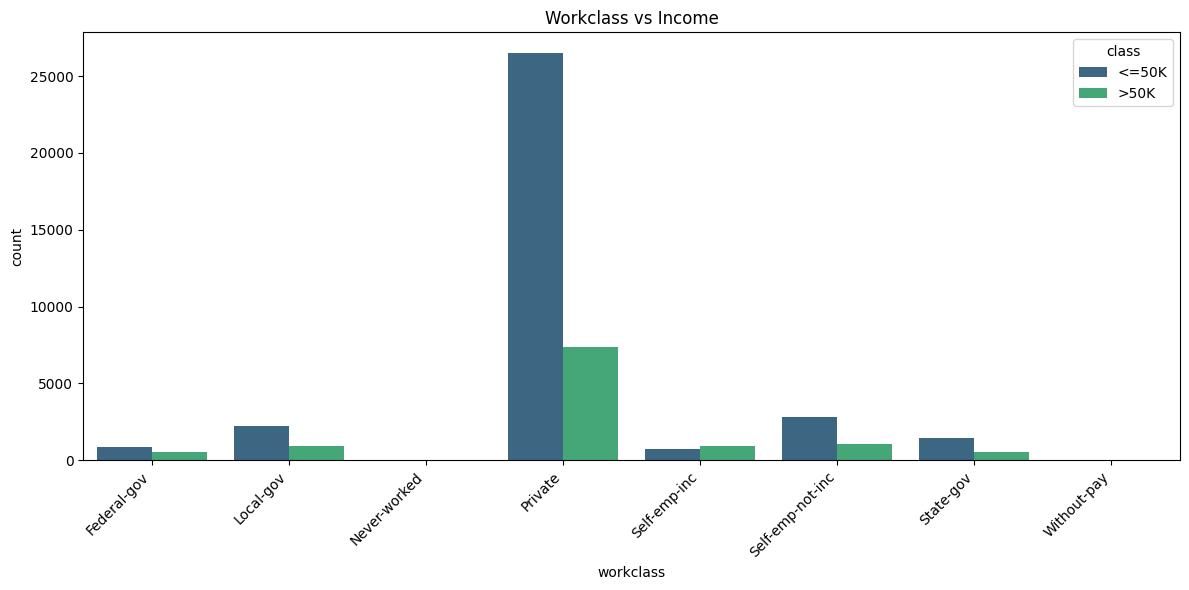

In [27]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='workclass', hue='class', palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title("Workclass vs Income")
plt.tight_layout()
plt.show()


## Melyik kategóriában mekkora a >50K arány?

Ez valódi business insight, és Data Science óra anyagnak kiváló.

Az alábbi notebook-cella:

- kiszámítja az arányt ( >50K / összes )
- rendezi csökkenő sorrendbe
- szép vízszintes barplotot készít
- címkézi is az értékeket

A példában most az education oszlopot használom, de bármely kategóriás oszlopra futtatható.

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Kategória kiválasztása ---
col = "education"   # <-- bármelyik kategória ide írható

# --- Arányok számítása (>50K arány) ---
# A target oszlop neve nálad 'class' (nem income!)
ratio_df = (
    df.groupby(col)['class']
    .apply(lambda x: (x == '>50K').mean())
    .sort_values(ascending=False)
)

ratio_df


/tmp/ipython-input-3483070695.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col)['class']


,class
education,
Prof-school,0.739808
Doctorate,0.725589
Masters,0.549116
Bachelors,0.412835
Assoc-acdm,0.257964
Assoc-voc,0.253275
Some-college,0.189649
HS-grad,0.158578
12th,0.073059


/tmp/ipython-input-4034820948.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


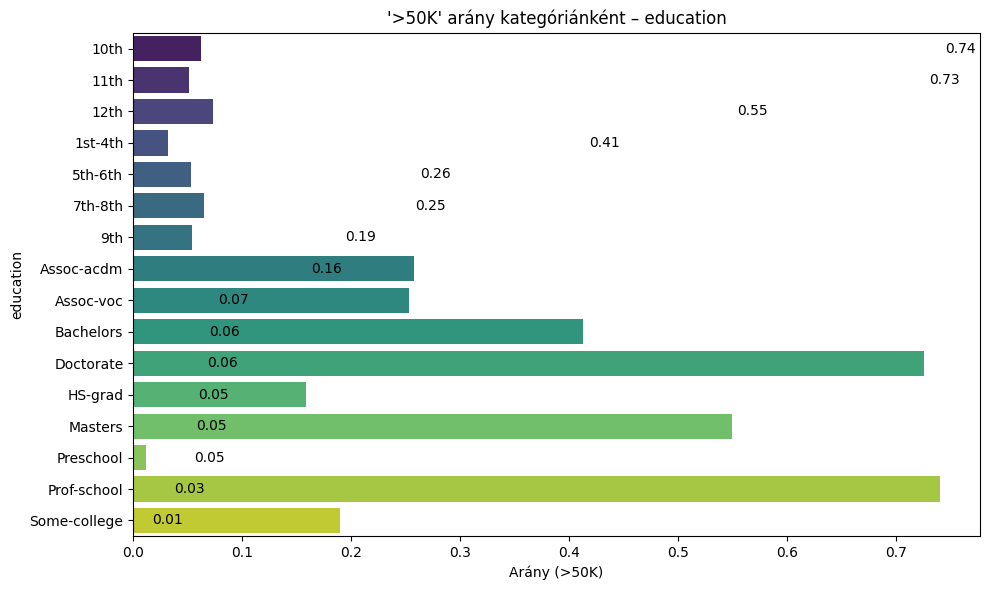

In [29]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x=ratio_df.values,
    y=ratio_df.index,
    palette="viridis"
)

plt.title(f"'>50K' arány kategóriánként – {col}")
plt.xlabel("Arány (>50K)")
plt.ylabel(col)

# Értékek kiírása a csíkok végére
for i, v in enumerate(ratio_df.values):
    plt.text(v + 0.005, i, f"{v:.2f}", va='center')

plt.tight_layout()
plt.show()


Magyarázat:

- a populáció 3-6% Prof-School vagy Doktor
- viszont 70% feletti esély arra, hogy ők 50k felett keresnek

/tmp/ipython-input-2605730341.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


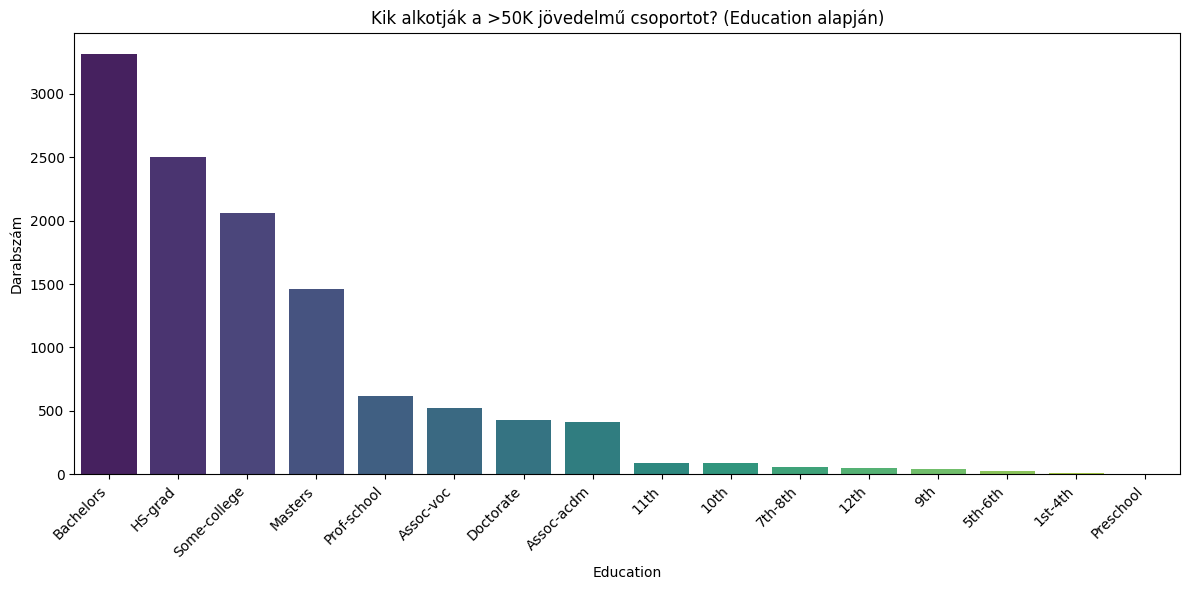

In [30]:
# Csak a >50K csoport kiválasztása
df_high = df[df['class'] == '>50K']
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df_high,
    x='education',
    order=df_high['education'].value_counts().index,
    palette='viridis'
)
plt.title("Kik alkotják a >50K jövedelmű csoportot? (Education alapján)")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Darabszám")
plt.xlabel("Education")
plt.tight_layout()
plt.show()


## A végzettség hatását torzíthatja a származási ország (native-country), mert ott eltérhet az átlagjövedelem és a munkapiac szerkezete.

Az Adult Income datasetben az USA dominál (~44 000 rekord),
a többi ország lényegében csak marginális mennyiségű adat.

Ezért:
- ha csak USA-ból jön az adat, akkor fair az összehasonlítás,
- ha nem, akkor normalizálni kell országonként.



In [32]:
ratio_country_edu = (
    df.groupby(['native-country', 'education'])['class']
      .apply(lambda x: (x == '>50K').mean())
      .reset_index()
)

ratio_country_edu.head()


/tmp/ipython-input-3137660377.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['native-country', 'education'])['class']


,native-country,education,class
0,Cambodia,10th,NaN
1,Cambodia,11th,NaN
2,Cambodia,12th,1.0
3,Cambodia,1st-4th,0.0
4,Cambodia,5th-6th,NaN


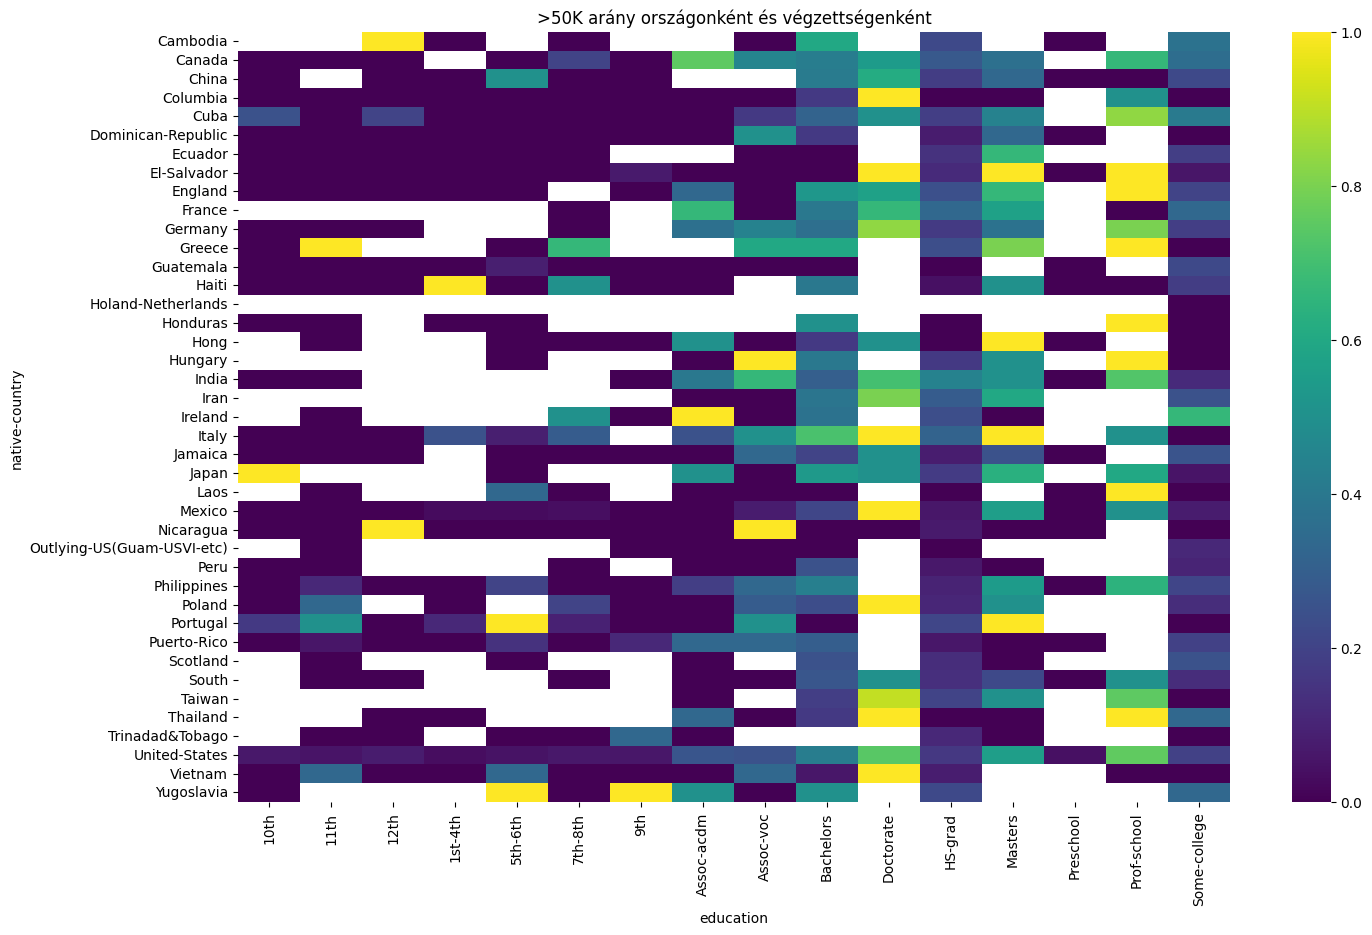

In [33]:
pivot = ratio_country_edu.pivot(
    index='native-country',
    columns='education',
    values='class'
)

plt.figure(figsize=(16, 10))
sns.heatmap(pivot, cmap='viridis', annot=False)
plt.title(">50K arány országonként és végzettségenként")
plt.show()


## “Weighted analysis”

Sok ország nagyon kicsi mintát ad → instabil arány.

Ilyenkor elég:
- Minimum mintaméret küszöb (pl. országok, ahol legalább 200 minta van)

In [36]:
valid_countries = df['native-country'].value_counts()
valid_countries = valid_countries[valid_countries > 200].index

df_valid = df[df['native-country'].isin(valid_countries)]


/tmp/ipython-input-2988692905.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


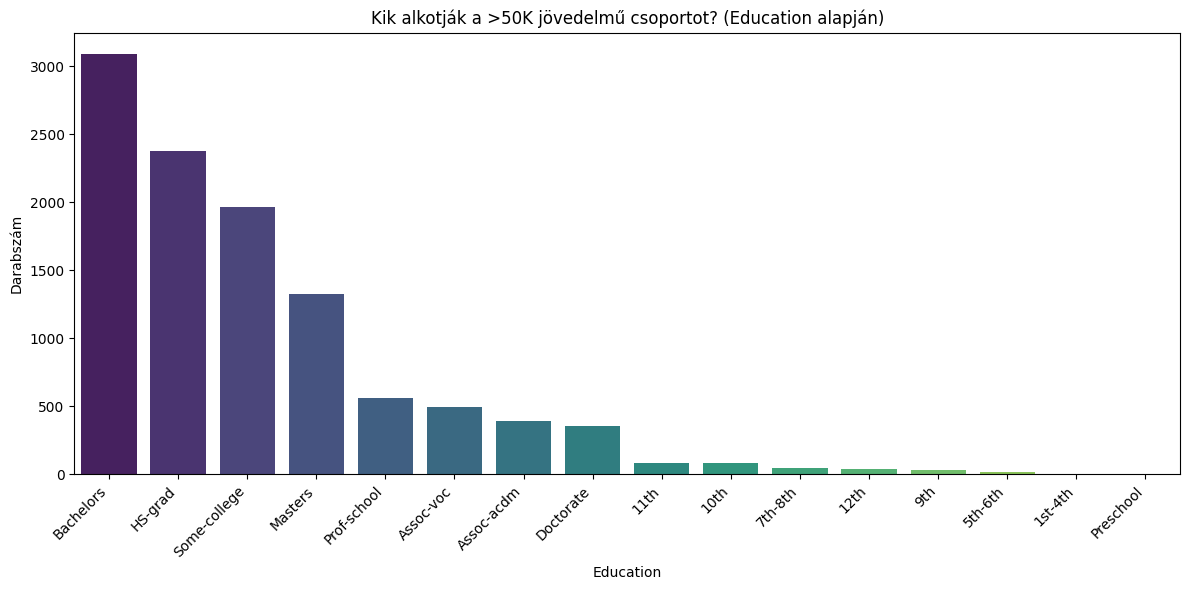

In [37]:
# Csak a >50K csoport kiválasztása
df_high = df_valid[df_valid['class'] == '>50K']
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df_high,
    x='education',
    order=df_high['education'].value_counts().index,
    palette='viridis'
)
plt.title("Kik alkotják a >50K jövedelmű csoportot? (Education alapján)")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Darabszám")
plt.xlabel("Education")
plt.tight_layout()
plt.show()

<Axes: xlabel='native-country'>

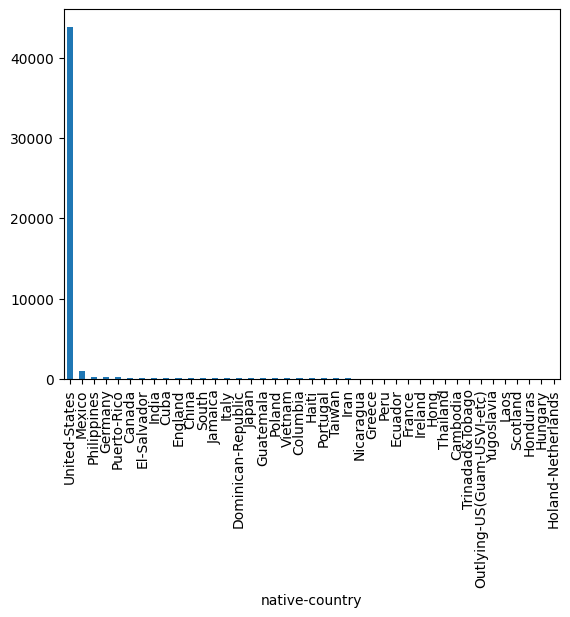

In [39]:
# Országonként a végzettség eloszlása (population bias ellen)
df['native-country'].value_counts().plot(kind='bar')


“Biztos, hogy a Bachelors keres sokat, vagy csak sok Bachelors van?”

## Országmérettel korrigált `>50K` esély – Miért fontos ez?

A nyers `>50K` arány országonként nagyon félrevezető lehet, mert a legtöbb országban:
- nagyon kevés minta van,
- a populáció összetétele (végzettség, munkakör) teljesen más,
- ezért a **nyers arány nem mutatja meg**, hogy egy adott végzettség valóban *erősebb vagy gyengébb hatással* van-e az adott országon BELÜL.

Ezért kiszámítjuk a következőt:

### **Ország + végzettség szerinti >50K arány**
majd ebből kivonjuk:

### **Az adott ország teljes, átlagos >50K arányát (baseline)**

Így megkapjuk:

# **“Mennyivel nagyobb/kisebb a >50K esély az adott végzettséggel, mint ami az országban általában várható?”**

Ez egy **lokális, országon belüli hatást** mutat:

- +0.20 → az adott végzettség **erős pozitív hatású** az országon belül  
- 0.00 → az adott végzettség **nem tér el** az ország átlagos jövedelmi szintjétől  
- –0.15 → az adott végzettség **gyengébb, mint az ország átlaga**

Ez segít különválasztani:
- az ország gazdasági fejlettségét  
- a végzettség valódi hatását  

Így tisztábban látszik, hogy **hol mely végzettség számít igazán, és mennyire**.


In [55]:
country_base = df.groupby("native-country")['class'].apply(lambda x: (x==">50K").mean())

group = df.groupby(["native-country", "education"])['class']
local = group.apply(lambda x: (x==">50K").mean())

normalized = local - country_base.loc[local.index.get_level_values(0)].values

normalized_table = normalized.unstack(fill_value=0)

# Sorok rendezése országonkénti átlag eltérés alapján (opcionális)
normalized_table = normalized_table.loc[
    normalized_table.mean(axis=1).sort_values(ascending=False).index
]

normalized_table.head()


/tmp/ipython-input-1442307502.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  country_base = df.groupby("native-country")['class'].apply(lambda x: (x==">50K").mean())
/tmp/ipython-input-1442307502.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(["native-country", "education"])['class']


education,10th,11th,12th,1st-4th,5th-6th,7th-8th,9th,Assoc-acdm,Assoc-voc,Bachelors,Doctorate,HS-grad,Masters,Preschool,Prof-school,Some-college
native-country,,,,,,,,,,,,,,,,
El-Salvador,-0.070968,-0.070968,-0.070968,-0.070968,-0.070968,-0.070968,-0.004301,-0.070968,-0.070968,-0.070968,0.929032,0.046679,0.929032,-0.070968,0.929032,-0.015412
Greece,-0.367347,0.632653,NaN,NaN,-0.367347,0.299320,NaN,NaN,0.232653,0.232653,NaN,-0.132053,0.432653,NaN,0.632653,-0.367347
Thailand,NaN,NaN,-0.166667,-0.166667,NaN,NaN,NaN,0.166667,-0.166667,0.000000,0.833333,-0.166667,-0.166667,NaN,0.833333,0.166667
Mexico,-0.049422,-0.049422,-0.049422,-0.020295,-0.021644,-0.011447,-0.049422,-0.049422,0.027501,0.159881,0.950578,0.012376,0.506134,-0.049422,0.450578,0.027501
Portugal,-0.012438,0.320896,-0.179104,-0.067993,0.820896,-0.088195,-0.179104,-0.179104,0.320896,-0.179104,NaN,0.029229,0.820896,NaN,NaN,-0.179104


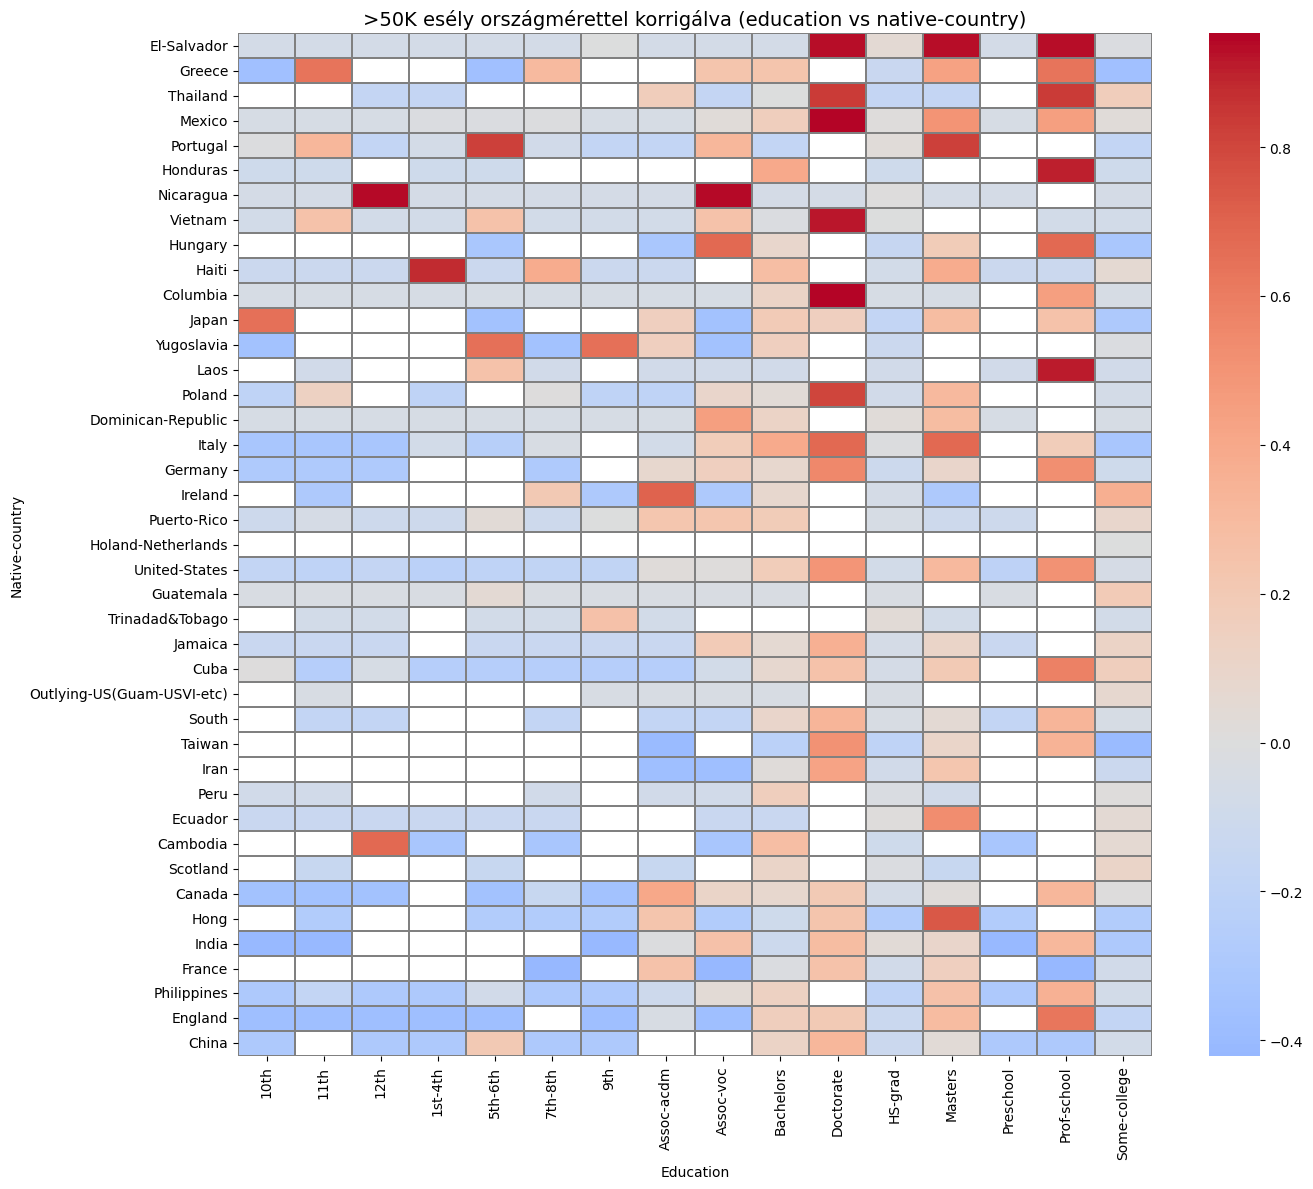

In [56]:
plt.figure(figsize=(14, 12))
sns.heatmap(
    normalized_table,
    cmap="coolwarm",
    center=0,  # középre állítjuk a nullát
    linewidths=0.3,
    linecolor="gray"
)
plt.title(">50K esély országmérettel korrigálva (education vs native-country)", fontsize=14)
plt.xlabel("Education")
plt.ylabel("Native-country")
plt.tight_layout()
plt.show()


- Ez a hőtérkép azt mutatja, hogy az egyes országokban az egyes végzettségekhez képest **mennyivel magasabb vagy alacsonyabb a >50K kereseti esély**, mint az adott ország átlagában.  
 -Pozitív (piros) érték azt jelzi, hogy az adott végzettség az adott országban **átlag feletti kereseti előnyt** ad, míg a negatív (kék) érték **átlag alatti esélyt** jelent.  
- Ez segít kiszűrni az országméret torzítását, és valós összehasonlítást ad arról, hogy hol mely végzettségek nyújtanak valódi jövedelmi előnyt.


## Oktatás és magas jövedelem korrelációja

A heatmap alapján vizuálisan is jól látható, hogy a magasabb végzettségű kategóriákban
nagyobb arányban fordul elő a >50K kereset.  
Ezt statisztikailag is alátámaszthatjuk úgy, hogy:

1. **A kategóriás “education” mezőt numerikus skálára képezzük**, a valós oktatási szint sorrendje szerint.  
2. **A jövedelmet binárissá alakítjuk**: >50K = 1, <=50K = 0.  
3. **Kiszámítjuk a korrelációt**, amely megmutatja, mennyire erős a kapcsolat a végzettségi szint és a magas jövedelem között.

A pozitív korreláció azt fogja jelenteni, hogy minél magasabb az oktatási szint, annál nagyobb az esélye a >50K keresetnek.


In [51]:
# Oktatási kategóriák rangsora (UCI Adult dataset standard sorrendje)
education_order = [
    'Preschool', '1st-4th', '5th-6th', '7th-8th', '9th',
    '10th', '11th', '12th', 'HS-grad', 'Some-college',
    'Assoc-voc', 'Assoc-acdm', 'Bachelors', 'Masters',
    'Prof-school', 'Doctorate'
]

# Rangsor (0-tól indul)
education_rank = {level: i for i, level in enumerate(education_order)}

df['education_rank'] = df['education'].map(education_rank)
df['income_binary'] = (df['class'] == '>50K').astype(int)


In [52]:
spearman_corr = df[['education_rank', 'income_binary']].corr(method='spearman')
spearman_corr


,education_rank,income_binary
education_rank,1.000000,0.327815
income_binary,0.327815,1.000000


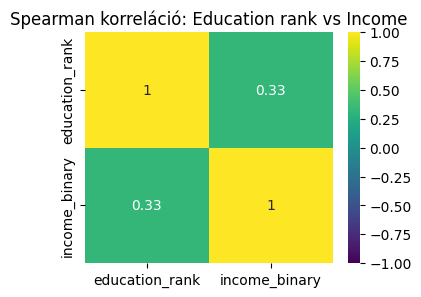

In [53]:
plt.figure(figsize=(4, 3))
sns.heatmap(spearman_corr, annot=True, cmap='viridis', vmin=-1, vmax=1)
plt.title("Spearman korreláció: Education rank vs Income")
plt.show()


Magyarázat:

- ahogy nő a végzettségi szint,
- úgy monoton módon nő a >50K esélye,
- a kapcsolat közepesen erős, statisztikailag szignifikáns.

Ez alátámasztja numerikusan is azt, amit az arányokból és a heatmapből vizuálisan láttál.

In [57]:
category = "occupation"    # <-- csak ezt írd át más kategóriára

# Országszintű alap esély (>50K)
country_base = df.groupby("native-country")['class'].apply(lambda x: (x==">50K").mean())

# Kategória x Ország
group = df.groupby(["native-country", category])['class']

# Lokális >50K arány
local = group.apply(lambda x: (x==">50K").mean())

# Normalizálás ország alaphoz képest
normalized = local - country_base.loc[local.index.get_level_values(0)].values

# Tábla formátum
normalized_table = normalized.unstack(fill_value=0)

# Opcionális: rendezzük az országokat az átlaghatás alapján
normalized_table = normalized_table.loc[
    normalized_table.mean(axis=1).sort_values(ascending=False).index
]

normalized_table.head()


/tmp/ipython-input-60396164.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  country_base = df.groupby("native-country")['class'].apply(lambda x: (x==">50K").mean())
/tmp/ipython-input-60396164.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(["native-country", category])['class']


occupation,Adm-clerical,Armed-Forces,Craft-repair,Exec-managerial,Farming-fishing,Handlers-cleaners,Machine-op-inspct,Other-service,Priv-house-serv,Prof-specialty,Protective-serv,Sales,Tech-support,Transport-moving
native-country,,,,,,,,,,,,,,
Portugal,-0.012438,NaN,-0.067993,0.820896,0.154229,-0.179104,-0.045771,-0.012438,NaN,NaN,-0.179104,0.154229,NaN,0.820896
Haiti,-0.120000,NaN,0.046667,NaN,-0.120000,0.213333,0.022857,-0.120000,-0.120000,0.546667,-0.120000,-0.120000,0.880000,0.046667
Mexico,-0.011686,NaN,0.017692,0.142886,-0.033293,-0.030903,-0.028145,-0.030672,-0.049422,0.200578,0.350578,0.063786,0.236293,0.083912
Jamaica,-0.093890,NaN,0.144205,0.025157,NaN,-0.141509,-0.141509,-0.101509,-0.141509,0.222127,0.858491,-0.141509,0.058491,0.258491
El-Salvador,-0.070968,NaN,0.015989,0.929032,-0.070968,-0.070968,-0.070968,-0.035253,-0.070968,0.357604,-0.070968,0.095699,-0.070968,-0.070968


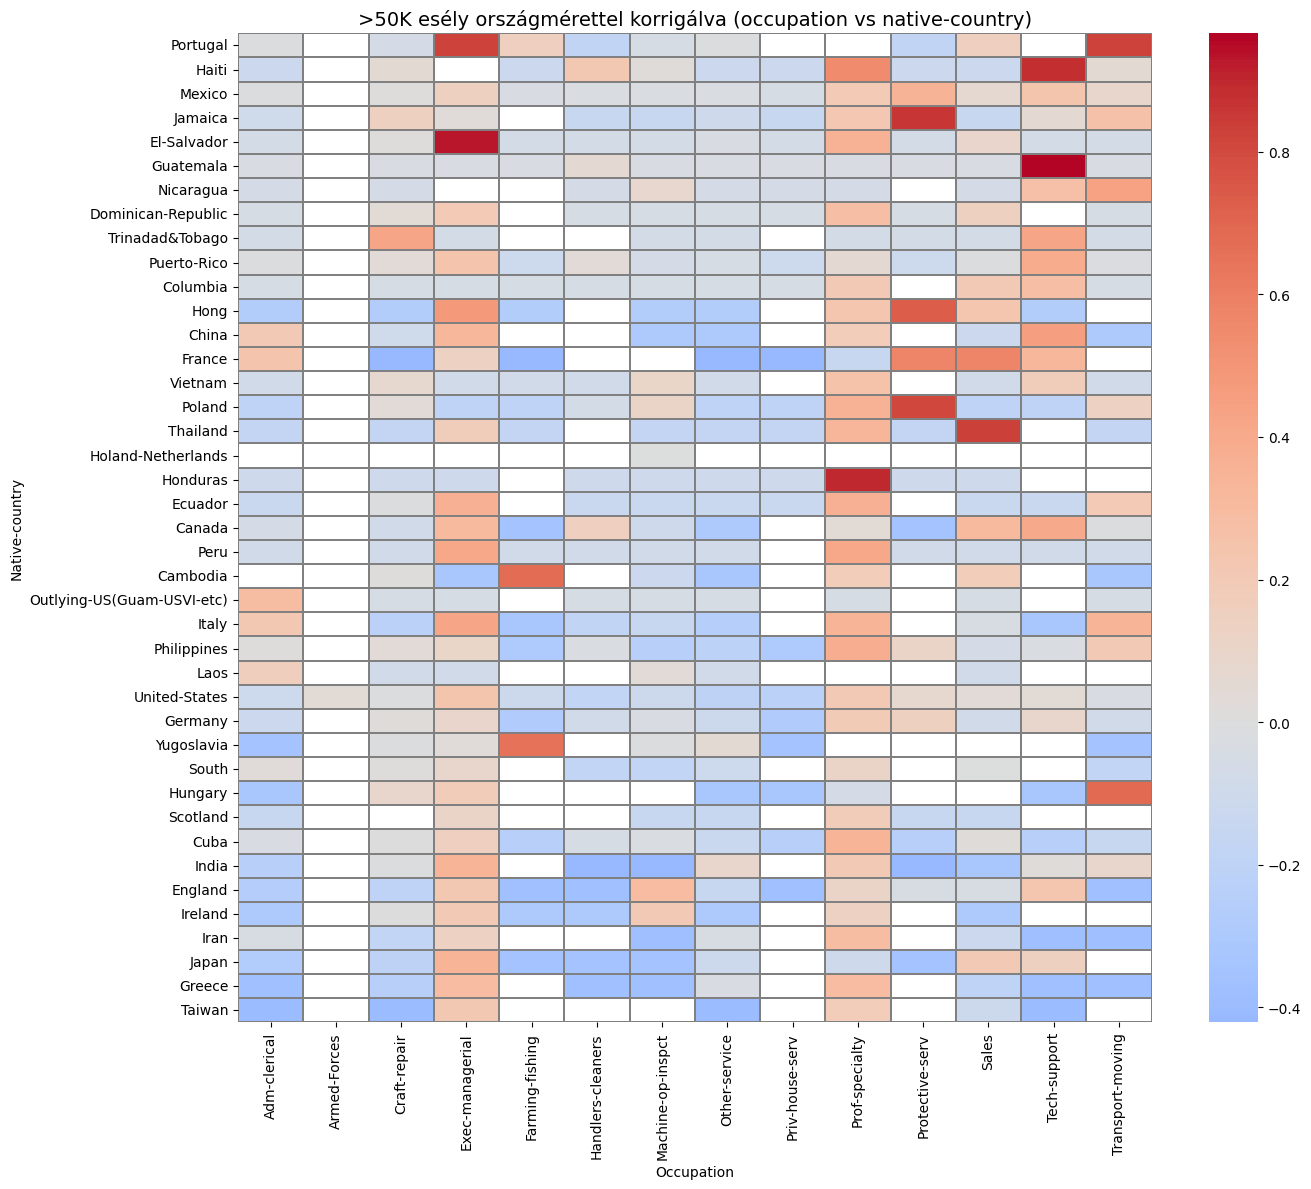

In [58]:
plt.figure(figsize=(14, 12))
sns.heatmap(
    normalized_table,
    cmap="coolwarm",
    center=0,
    linewidths=0.3,
    linecolor="gray"
)
plt.title(f">50K esély országmérettel korrigálva ({category} vs native-country)", fontsize=14)
plt.xlabel(category.capitalize())
plt.ylabel("Native-country")
plt.tight_layout()
plt.show()


In [59]:
category = "sex"    # <-- csak ezt írd át más kategóriára

# Országszintű alap esély (>50K)
country_base = df.groupby("native-country")['class'].apply(lambda x: (x==">50K").mean())

# Kategória x Ország
group = df.groupby(["native-country", category])['class']

# Lokális >50K arány
local = group.apply(lambda x: (x==">50K").mean())

# Normalizálás ország alaphoz képest
normalized = local - country_base.loc[local.index.get_level_values(0)].values

# Tábla formátum
normalized_table = normalized.unstack(fill_value=0)

# Opcionális: rendezzük az országokat az átlaghatás alapján
normalized_table = normalized_table.loc[
    normalized_table.mean(axis=1).sort_values(ascending=False).index
]

normalized_table.head()

/tmp/ipython-input-998794466.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  country_base = df.groupby("native-country")['class'].apply(lambda x: (x==">50K").mean())
/tmp/ipython-input-998794466.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(["native-country", category])['class']


sex,Female,Male
native-country,,
Jamaica,-0.089785,0.108491
Laos,0.024155,-0.015528
Trinadad&Tobago,-0.074074,0.079772
Honduras,-0.009091,0.011111
Holand-Netherlands,0.000000,NaN


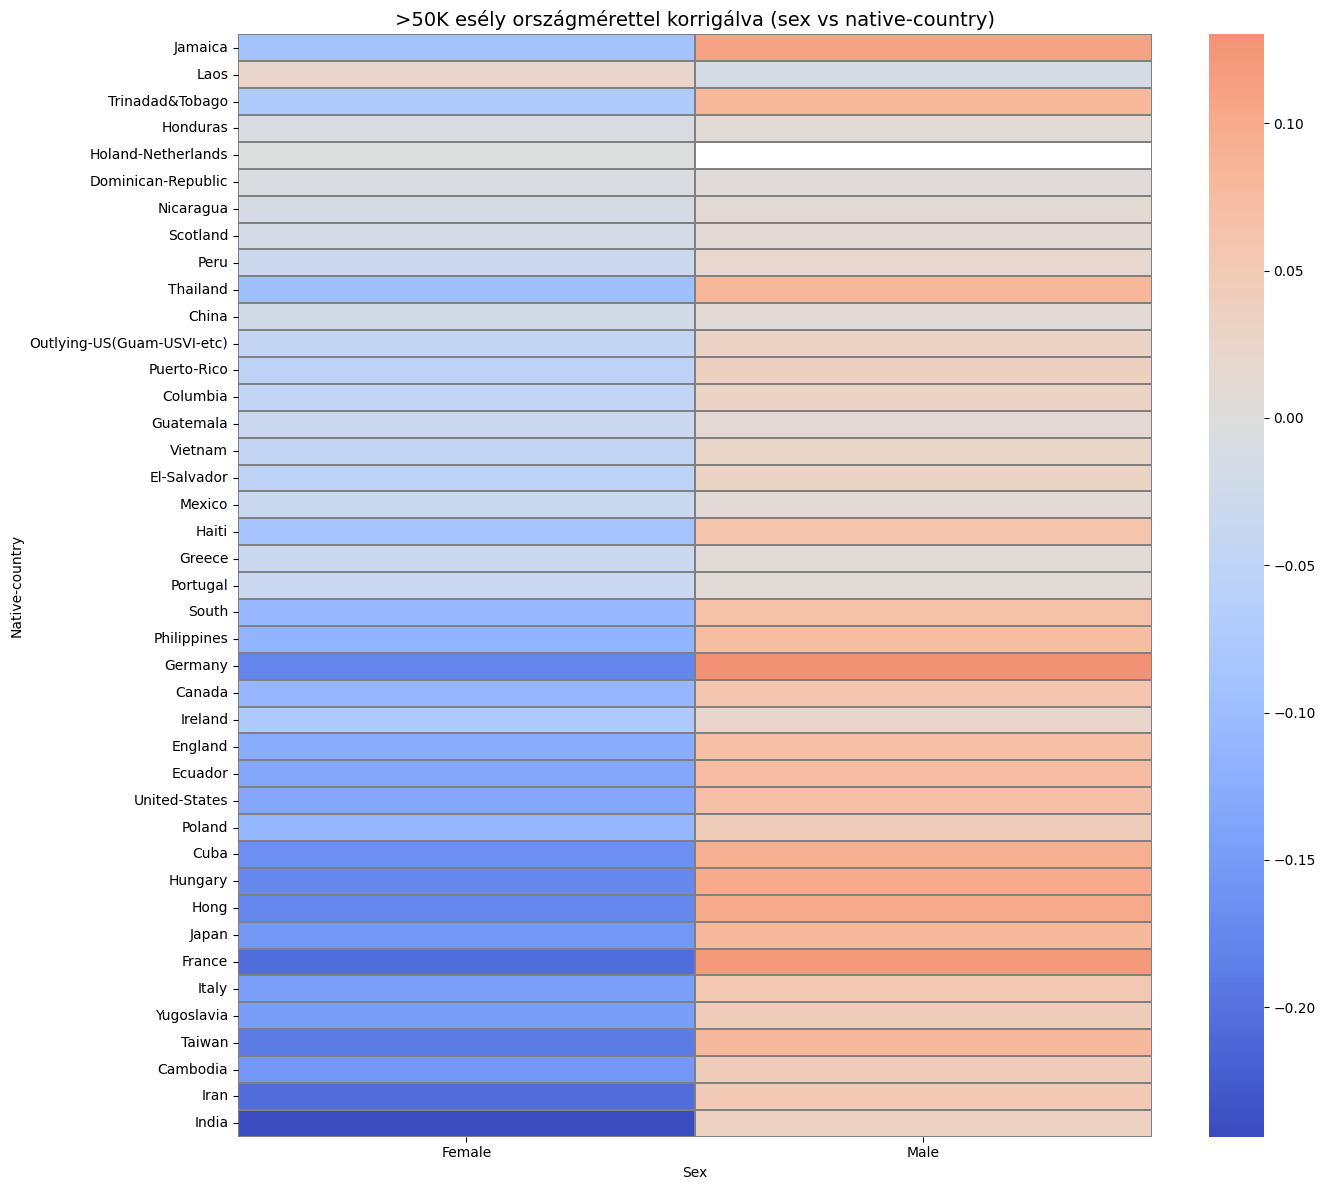

In [60]:
plt.figure(figsize=(14, 12))
sns.heatmap(
    normalized_table,
    cmap="coolwarm",
    center=0,
    linewidths=0.3,
    linecolor="gray"
)
plt.title(f">50K esély országmérettel korrigálva ({category} vs native-country)", fontsize=14)
plt.xlabel(category.capitalize())
plt.ylabel("Native-country")
plt.tight_layout()
plt.show()


## Hours-per-week kategorizálva (bins) + Income

A “hours-per-week” numerikus, de kategorizálva szinte úgy viselkedik, mint kategóriás változó:
- <35 óra → low-income
- 35–40 óra → baseline
- 41–55 óra → növekvő >50K esély
- 55 óra → nagyon magas >50K arány

Érdemes ebből kategóriákat képezni:

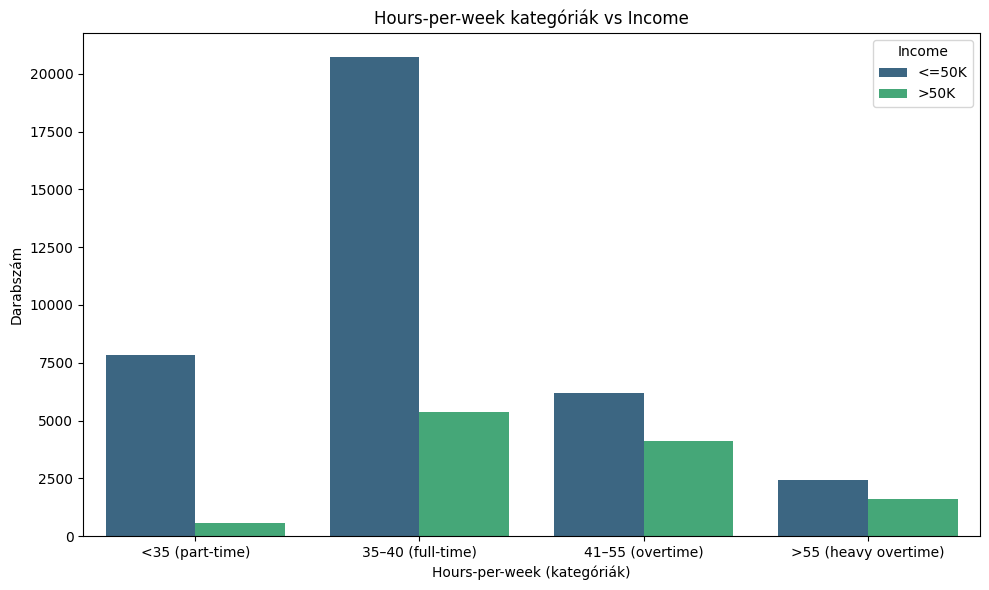

In [62]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Hours-per-week kategóriák létrehozása ---
bins = [0, 34, 40, 55, 100]   # felső határ bőven 100 felett
labels = ["<35 (part-time)", "35–40 (full-time)", "41–55 (overtime)", ">55 (heavy overtime)"]

df["hours_cat"] = pd.cut(df["hours-per-week"], bins=bins, labels=labels, right=True)

# --- Countplot income bontásban ---
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    x="hours_cat",
    hue="class",      # nálad a target neve 'class'
    palette="viridis"
)

plt.title("Hours-per-week kategóriák vs Income")
plt.xlabel("Hours-per-week (kategóriák)")
plt.ylabel("Darabszám")
plt.legend(title="Income")
plt.tight_layout()
plt.show()



/tmp/ipython-input-2582421570.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("hours_cat")["class"]
/tmp/ipython-input-2582421570.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


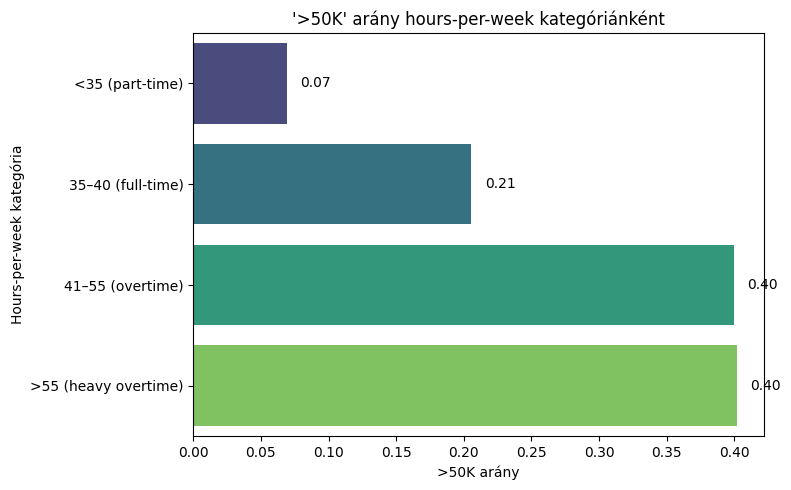

In [63]:
ratio_hp = (
    df.groupby("hours_cat")["class"]
    .apply(lambda x: (x == ">50K").mean())
    .sort_values()
)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=ratio_hp.values,
    y=ratio_hp.index,
    palette="viridis"
)

plt.title("'>50K' arány hours-per-week kategóriánként")
plt.xlabel(">50K arány")
plt.ylabel("Hours-per-week kategória")

for i, v in enumerate(ratio_hp.values):
    plt.text(v + 0.01, i, f"{v:.2f}", va="center")

plt.tight_layout()
plt.show()


## Scatterplot: Hours-per-week vs Age + Income színezés

Ez megmutatja:
- a >50K keresők többet dolgoznak,
- mely életkorokban a legmagasabb a kereset,
- a részmunkaidősök szinte mind <=50K.

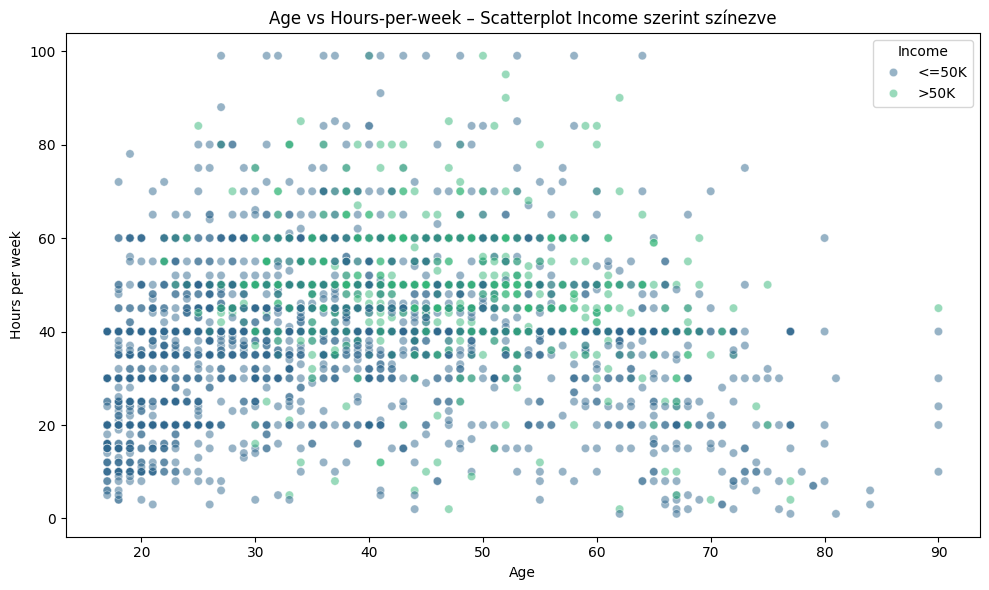

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df.sample(5000),   # mintavétel, hogy ne legyen 50k pont
    x="age",
    y="hours-per-week",
    hue="class",
    alpha=0.5,
    palette="viridis"
)

plt.title("Age vs Hours-per-week – Scatterplot Income szerint színezve")
plt.xlabel("Age")
plt.ylabel("Hours per week")
plt.legend(title="Income")
plt.tight_layout()
plt.show()


/tmp/ipython-input-3320990013.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


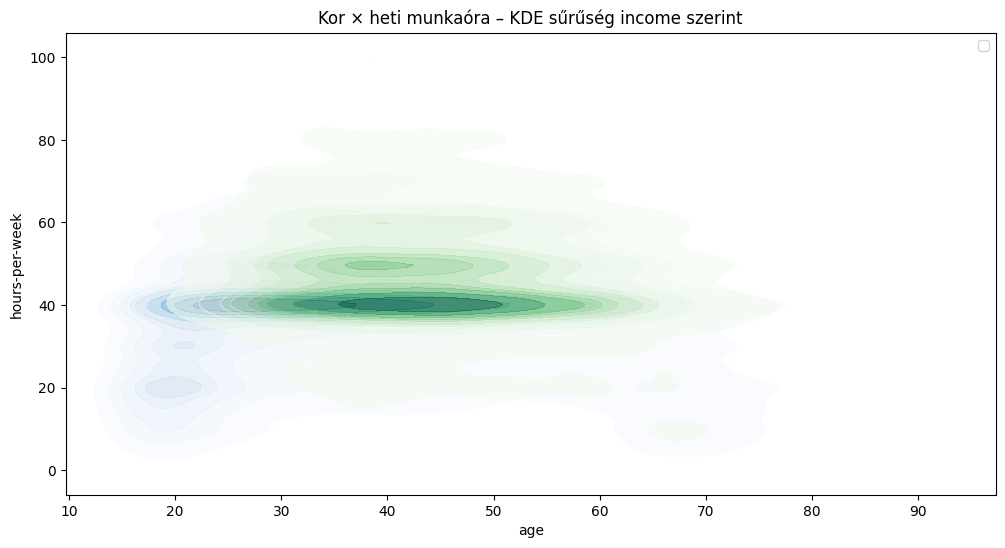

In [71]:
import seaborn as sns

plt.figure(figsize=(12,6))

sns.kdeplot(
    data=df[df["class"]=="<=50K"],
    x="age",
    y="hours-per-week",
    cmap="Blues",
    fill=True,
    thresh=0.05,
    alpha=0.6,
    label="<=50K"
)

sns.kdeplot(
    data=df[df["class"]==">50K"],
    x="age",
    y="hours-per-week",
    cmap="Greens",
    fill=True,
    thresh=0.05,
    alpha=0.6,
    label=">50K"
)

plt.legend()
plt.title("Kor × heti munkaóra – KDE sűrűség income szerint")
plt.show()


## SHAP alapú értelmezés (soft modeling)

Bár a célunk nem a predikció, egy nagyon egyszerű modell segítségével
megmutathatjuk, hogy **mely változók milyen irányban befolyásolják a jövedelmet**.

A SHAP értékek különösen hasznosak, mert:

- egységes skálán mutatják a hatás nagyságát,
- azt is jelzik, hogy **pozitív vagy negatív irányba** tol egy változó,
- és nagyon jól értelmezhetők üzleti/Data Science kontextusban is.

Itt nem a modell pontossága számít,
hanem az, hogy **a SHAP visszaigazolja-e az EDA során talált összefüggéseket**.


In [66]:
# --- Könyvtárak ---
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression

import shap
import matplotlib.pyplot as plt

# --- Target és feature-ek előkészítése ---
X = df.drop(columns=['class'])
y = (df['class'] == '>50K').astype(int)

# Kategóriás és numerikus mezők szétválasztása
cat_cols = X.select_dtypes(include=['category']).columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

# --- Preprocessing pipeline ---
preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ("num", "passthrough", num_cols)
])

# --- Egyszerű modell ---
model = Pipeline([
    ("preprocess", preprocess),
    ("clf", LogisticRegression(max_iter=1000))
])

# Tanítás
model.fit(X, y)

print("Model kész (nem predikcióra, hanem SHAP-hoz).")


Model kész (nem predikcióra, hanem SHAP-hoz).


/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


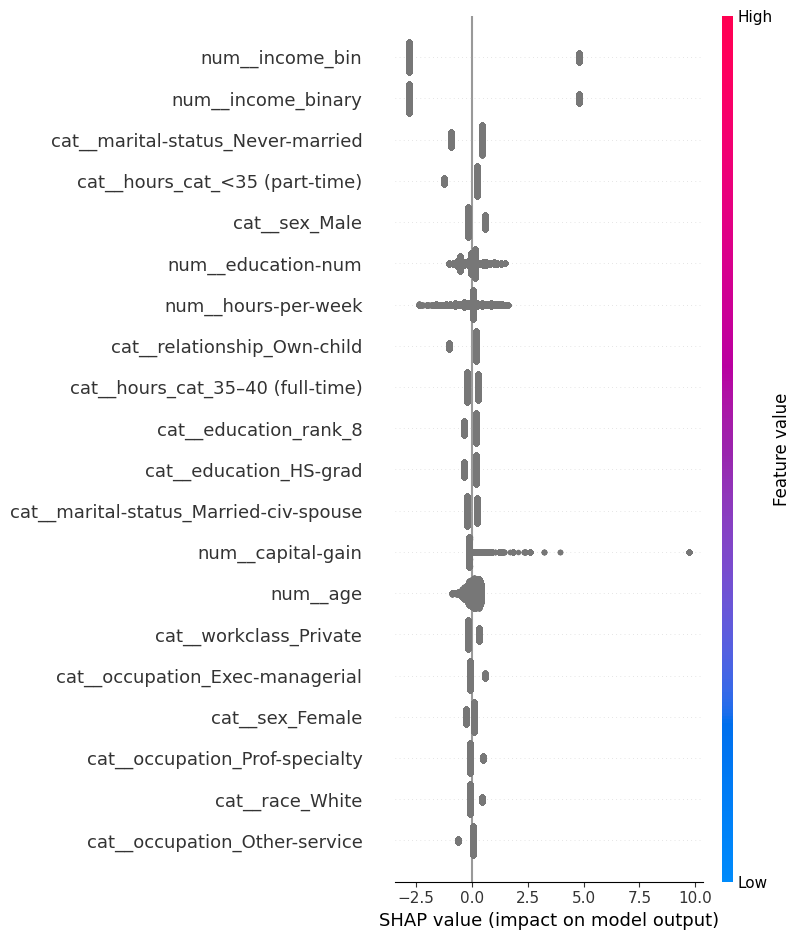

In [68]:
import shap
import numpy as np

# --- A pipeline részeinek szétbontása ---
preprocess = model['preprocess']
clf = model['clf']

# --- A bemenő mátrix transformálása ---
X_transformed = preprocess.transform(X)

# --- SHAP LinearExplainer (legjobb LR-hez) ---
explainer = shap.LinearExplainer(clf, X_transformed, feature_perturbation="interventional")

# --- SHAP értékek kiszámítása ---
shap_values = explainer.shap_values(X_transformed)

# --- Feature nevek ---
feature_names = preprocess.get_feature_names_out()

# --- Beeswarm ábra ---
shap.summary_plot(shap_values, features=X_transformed, feature_names=feature_names)



## Modellértelmezés SHAP értékekkel

A SHAP (SHapley Additive exPlanations) módszer megmutatja, hogy az egyes
változók milyen irányban és mekkora mértékben befolyásolják a modell döntését.
A fenti ábrán a nagyobb abszolút SHAP-értékek nagyobb hatást jelentenek
a jövedelmi kategória (>50K vs <=50K) előrejelzésében.

### Főbb megfigyelések:

- **Income bináris kódolása** (num_income_bin / num_income_binary) várhatóan a legerősebb prediktor.
- A modell erősen támaszkodik a **marital-status** és **hours-per-week** kategóriákra.
- A magasabb iskolai végzettséghez kapcsolódó bináris változók pozitív hatást mutatnak.
- A numerikus jellemzők közül az **age**, **capital-gain**, és **hours-per-week**
  emelkedése tipikusan növeli a >50K jövedelem valószínűségét.
- A kategóriák (pl. "sex_Male", "occupation_Exec-managerial") szintén
  markáns hatást mutatnak, összhangban az EDA során látottakkal.

A SHAP módszer különösen hasznos arra, hogy **összekapcsoljuk az EDA lépéseket
a modell értelmezésével**, és megmutassuk, hogyan építi fel a tanult összefüggéseket
a prediktív algoritmus.